# Great Lakes Basin MODFLOW 6 — Clean, ordered workflow

This notebook is a **reorganized version** of the input-preparation and model-run workflow.
It keeps the core logic from the original notebook, but it puts sections in a cleaner order,
removes most ad-hoc debugging cells, and adds clearer section comments so it is easier to
rerun from top to bottom.

## Recommended execution order
Run the notebook **sequentially** from top to bottom.  
If you change `id2d` / `idomain`, rerun all downstream sections that depend on the active domain:
- recharge
- GHB
- DRN
- plotting
- model build/run


## 0) Imports


In [1]:
import os
import gc
import time
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"  # helps reading NetCDF/HDF5 from network drives on Windows
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="pyogrio")
warnings.filterwarnings("ignore", category=DeprecationWarning)
from pathlib import Path
import re, glob, shutil, tempfile, calendar

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio as rio
from rasterio.transform import from_origin, from_bounds
from rasterio.features import rasterize
from rasterio.warp import reproject, Resampling
import shapely.geos
from shapely.geometry import MultiLineString
import matplotlib.pyplot as plt
import matplotlib as mpl
from rasterio.crs import CRS
import flopy
from flopy.utils.gridintersect import GridIntersect

import xarray as xr

print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {mpl.__version__}")
print(f"flopy version: {flopy.__version__}")

numpy version: 2.3.5
matplotlib version: 3.10.8
flopy version: 3.10.0


## 1) User settings

This section holds file paths, model options, package settings, and run controls.
Edit only this section when you need to change inputs or outputs.


In [70]:
# --- Model identity ---
nameSim   = "Greatlakes"
nameModel = "Testing_6"  # MF6 model name; package files will be Testing.dis, Testing.rch, etc.

# --- MF6 executable ---
bindir = Path(r"D:\Users\abolmaal\modelling\Modflow\helper")
exe_path = str((bindir / "mf6.exe").resolve())

# --- Simulation workspace (will be RECREATED) ---
dirModelFilesBase = r"D:\Users\abolmaal\modelling\Modflow"
sim_ws = str(Path(dirModelFilesBase) / nameModel)

# --- Boundary polygon (truth) ---
boundary_shp = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Ibound\extended_Bdry_final_GLB_Albers_exported.shp"

IBOUND = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Ibound\Idomain_mask_30m.tif"
# --- Raw rasters (any CRS/resolution; we will warp to template) ---
nameInputTop       = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\DEM\DEM_extended20kmbdr_1000m.tif"

nameInputLayBot    = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Bottom\modelbottom.tif"

nameInputHorizCond = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HK_5band_1000m.tif"


# this is the actual starting head raster
nameInputStrt     = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Wells\starting_heads_clamped_1000m.tif"

#this is your lake/land mask, NOT starting heads
#nameInputMask   = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\domain_water_mask_30m_buff2000m.tif"

# --- CHD / DRN vector inputs ---
pathInputConstHead      = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\CHD_cells_points_dem.shp"
fieldInputConstHeadElev = "head"

# -- GHB ---
OUT_GHB_TABLE = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes_GHB_cells.csv"
OUT_STAGE_TABLE = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes_stage_monthly_for_model.csv"

LAKES_SHP = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes.shp"


# pathInputDrn = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\NHD\streams_3174_clip_to_modelgrid.shp"
# fieldInputDrnWidth = "WIDTH_M"
USE_DRN = True
USE_WETLAND_DRN = False   # separate wetland DRN no longer needed

nameInputDrainElev = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Drains\drain_elevation.tif"
drain_elev_aligned = os.path.join(sim_ws, "drain_elevation_aligned.tif")
drain_presence_raw = os.path.join(sim_ws, "drain_presence_raw.tif")
drain_frac_aligned = os.path.join(sim_ws, "drain_fraction_aligned.tif")


DRN_K_DIVISOR = 1.0       # use 1.0 if you want exactly Kcell
# DRN_K_DIVISOR = 10.0    # use this instead if you want Kcell/10 for vertical leakage

DRN_MIN_THICK = 0.1       # minimum cell thickness used in conductance
DRN_MIN_AREA_FRAC = 0.01  # skip tiny drain fractions
DRN_COND_MULT = 1.0
DRN_ELEV_EPS = 0.01       # keep drain elevation slightly inside the cell

# --- NLDAS monthly Noah (NetCDF) ---
nldas_root = Path(r"D:\Users\abolmaal\Data\Downloaded\Climatedata\Gridded\NLDAS_NOAHVIC_M.2.0")
NLDAS_VAR  = "Qsb"

# --- Model grid definition ---
CELL = 1000       # meters (try 2000 or 1000 later)
EPSG = 3174       # NAD_1983_Great_Lakes_Basin_Albers

# --- Outputs (template + warped rasters) ---
GRID_DIR    = Path(r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\GRID_3174")
ALIGNED_DIR = Path(r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\ALIGNED_3174")
GRID_DIR.mkdir(parents=True, exist_ok=True)
ALIGNED_DIR.mkdir(parents=True, exist_ok=True)

template_tif = str(GRID_DIR / f"template_{CELL}m_epsg{EPSG}.tif")
idomain_tif  = str(GRID_DIR / f"idomain_{CELL}m_epsg{EPSG}.tif")

top_aligned   = str(ALIGNED_DIR / f"TOP_{CELL}m.tif")
botm_aligned  = str(ALIGNED_DIR / f"BOTM_{CELL}m.tif")
hk_aligned    = str(ALIGNED_DIR / f"HK_{CELL}m.tif")
mask_aligned  = str(ALIGNED_DIR / f"MASK_{CELL}m.tif")
strt_aligned  = str(ALIGNED_DIR / f"STRT_{CELL}m.tif")
Ibound_aligned = str(ALIGNED_DIR / f"IBOUND_{CELL}m.tif")

# --- Streams source for DRN build ---
gdb_path = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\NHD\streams_tmp.gdb"
layer_name = "streams_3174"   # change if your FileGDB layer name differs

# --- Time controls ---
START_DATE = "2020-01-01"
END_DATE   = "2023-12-01"

NPER_TEST =13          # set None for full run
USE_FIVE_LAYER_MODEL = True
FORCE_CONSTANT_CHD = False
LAKE_STAGE = 100.0
USE_GHB = True
USE_DRN = True

# =========================================================
# WETLAND DRN SETTINGS
# =========================================================
# USE_WETLAND_DRN = True

# WETLANDS_SHP = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Wetlands\Wetlands_GL_NoLakes.shp"

# WETLAND_TSED_M = 1.0
# WETLAND_KV_DIVISOR = 10.0
# WETLAND_DEPTH_BELOW_LAND_M = 0.1

# Figure_dir 
fig_dir = r"D:\Users\abolmaal\modelling\Figs\testing6"

## 2) Helper functions

All reusable helper functions are grouped here so the rest of the notebook can stay short and readable.
This includes:
- grid/template helpers
- raster read/write helpers
- recharge helpers
- GHB helpers
- DRN helper builders


In [3]:

def snap_bounds_to_cell(bounds, cell):
    xmin, ymin, xmax, ymax = bounds
    xmin = np.floor(xmin / cell) * cell
    ymin = np.floor(ymin / cell) * cell
    xmax = np.ceil(xmax / cell) * cell
    ymax = np.ceil(ymax / cell) * cell
    return float(xmin), float(ymin), float(xmax), float(ymax)

def build_model_months(start_date, nper):
    return pd.date_range(start=start_date, periods=nper, freq="MS")

def build_monthly_perioddata(start="2000-01-01", end="2025-12-01", nstp=1, tsmult=1.0):
    months = pd.date_range(start=start, end=end, freq="MS")
    pddata = []
    for d in months:
        ndays = calendar.monthrange(d.year, d.month)[1]
        pddata.append((float(ndays), int(nstp), float(tsmult)))
    return pddata, months

def make_template_from_boundary(boundary_shp, out_template_tif, cellsize):
    gdf = gpd.read_file(boundary_shp)

    if gdf.crs is None:
        raise ValueError(f"Boundary file has no CRS: {boundary_shp}")

    xmin, ymin, xmax, ymax = snap_bounds_to_cell(gdf.total_bounds, cellsize)

    width = int(round((xmax - xmin) / cellsize))
    height = int(round((ymax - ymin) / cellsize))

    from rasterio.transform import from_origin
    transform = from_origin(xmin, ymax, cellsize, cellsize)

    profile = {
        "driver": "GTiff",
        "height": height,
        "width": width,
        "count": 1,
        "dtype": "int16",
        "transform": transform,
        "nodata": 0,
        "compress": "deflate",
        "tiled": True,
        "BIGTIFF": "YES",
    }

    if os.path.exists(out_template_tif):
        try:
            os.remove(out_template_tif)
        except PermissionError:
            print("Could not delete locked file:", out_template_tif)

    with rio.open(out_template_tif, "w", **profile) as dst:
        import numpy as np
        dst.write(np.zeros((height, width), dtype=np.int16), 1)

    return out_template_tif


def rasterize_idomain(boundary_shp, template_tif, out_idomain_tif, burn_value=1, all_touched=False):
    """
    Rasterize boundary directly onto template grid.
    Assumes boundary_shp is already in the same CRS as the intended grid.
    """
    gdf = gpd.read_file(boundary_shp)

    if gdf.crs is None:
        raise ValueError(f"Boundary file has no CRS: {boundary_shp}")

    with rio.open(template_tif) as tmp:
        arr = rasterize(
            shapes=[(geom, burn_value) for geom in gdf.geometry if geom is not None and not geom.is_empty],
            out_shape=(tmp.height, tmp.width),
            transform=tmp.transform,
            fill=0,
            dtype="int32",
            all_touched=all_touched
        )

        profile = tmp.profile.copy()
        profile.update(
            driver="GTiff",
            dtype="int32",
            count=1,
            nodata=0,
            compress="deflate",
            tiled=True,
            BIGTIFF="YES"
        )

        # optional: strip fields that sometimes cause trouble when copied through
        profile.pop("blockxsize", None)
        profile.pop("blockysize", None)

    if os.path.exists(out_idomain_tif):
        try:
            os.remove(out_idomain_tif)
        except PermissionError:
            print("Could not delete locked file:", out_idomain_tif)

    with rio.open(out_idomain_tif, "w", **profile) as dst:
        dst.write(arr, 1)

    return out_idomain_tif

def assert_match_template_no_crs(raster_tif, template_tif, name="Raster"):
    """
    Check shape and transform only. Skip CRS because Rasterio cannot
    reliably read CRS in the current environment.
    """
    with rio.open(raster_tif) as a, rio.open(template_tif) as b:
        if (a.height, a.width) != (b.height, b.width):
            raise AssertionError(
                f"{name} shape mismatch: {(a.height, a.width)} vs {(b.height, b.width)}"
            )
        if a.transform != b.transform:
            raise AssertionError(
                f"{name} transform mismatch:\n{a.transform}\nvs\n{b.transform}"
            )
    print(f"{name} matches template in shape and transform.")




def warp_raster_to_template(src_path, template_path, out_path, resampling, dst_nodata=-9999.0):
    with rio.open(template_path) as tmpl, rio.open(src_path) as src:
        dst_meta = src.meta.copy()
        dst_meta.update(
            driver="GTiff",
            crs=tmpl.crs,
            transform=tmpl.transform,
            width=tmpl.width,
            height=tmpl.height,
            nodata=dst_nodata,
            compress="deflate",
            tiled=True,
            BIGTIFF="YES",
            blockxsize=256,
            blockysize=256,
        )
        with rio.open(out_path, "w", **dst_meta) as dst:
            for b in range(1, src.count + 1):
                reproject(
                    source=rio.band(src, b),
                    destination=rio.band(dst, b),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    src_nodata=src.nodata,
                    dst_transform=tmpl.transform,
                    dst_crs=tmpl.crs,
                    dst_nodata=dst_nodata,
                    resampling=resampling,
                )
    return out_path

def assert_match_template(path, template_path, name):
    with rio.open(template_path) as t, rio.open(path) as s:
        assert (s.height, s.width) == (t.height, t.width), f"{name} shape mismatch"
        assert s.crs == t.crs, f"{name} CRS mismatch"
        assert s.transform == t.transform, f"{name} transform mismatch"

def read_band1(path, dtype="float32"):
    with rio.open(path) as src:
        return src.read(1).astype(dtype, copy=False), src.nodata

def read_all_bands(path, dtype="float32"):
    with rio.open(path) as src:
        return src.read().astype(dtype, copy=False), src.nodata

def clean_continuous(a, nodata, fill=0.0):
    a = a.astype("float32", copy=False)
    a = np.nan_to_num(a, nan=fill, posinf=fill, neginf=fill)
    if nodata is not None:
        a = np.where(a == nodata, fill, a)
    return a

def make_gridintersect(modelgrid):
    try:
        return GridIntersect(modelgrid, method="vertex")
    except TypeError:
        try:
            return GridIntersect(modelgrid, "vertex")
        except TypeError:
            return GridIntersect(modelgrid)

def update_ghb_k_from_idomain(ghb_cells_df, idomain):
    """
    Update GHB layer k so each boundary cell is assigned to the first active layer
    at its (i, j) location based on the final DIS idomain.
    """
    df = ghb_cells_df.copy()

    if {"i", "j"}.issubset(df.columns):
        i_col, j_col = "i", "j"
    elif {"row", "col"}.issubset(df.columns):
        i_col, j_col = "row", "col"
        if "i" not in df.columns:
            df["i"] = df["row"]
        if "j" not in df.columns:
            df["j"] = df["col"]
    else:
        raise ValueError("ghb_cells_df must contain either (i, j) or (row, col) columns.")

    if idomain.ndim == 2:
        active = idomain > 0
        keep_idx = []
        new_k = []
        for idx, r in enumerate(df.itertuples(index=False)):
            i = int(getattr(r, i_col))
            j = int(getattr(r, j_col))
            if 0 <= i < active.shape[0] and 0 <= j < active.shape[1] and active[i, j]:
                keep_idx.append(idx)
                new_k.append(0)
        df = df.iloc[keep_idx].copy()
        df["k"] = new_k
        return df.reset_index(drop=True)

    if idomain.ndim == 3:
        nlay, nrow, ncol = idomain.shape
        keep_idx = []
        new_k = []
        for idx, r in enumerate(df.itertuples(index=False)):
            i = int(getattr(r, i_col))
            j = int(getattr(r, j_col))
            if not (0 <= i < nrow and 0 <= j < ncol):
                continue
            active_layers = np.where(idomain[:, i, j] > 0)[0]
            if len(active_layers) == 0:
                continue
            keep_idx.append(idx)
            new_k.append(int(active_layers[0]))
        df = df.iloc[keep_idx].copy()
        df["k"] = new_k
        return df.reset_index(drop=True)

    raise ValueError(f"idomain must be 2D or 3D, got shape {idomain.shape}")

def assign_ghb_k_from_stage_floor(ghb_cells_df, idomain, botm3d, stage_floor_by_name, stage_margin=0.05):
    """
    Choose the shallowest active layer whose bottom is below the minimum
    stage for that lake/stage_name.

    Parameters
    ----------
    ghb_cells_df : DataFrame
        Must contain stage_name, i, j
    idomain : ndarray
        3D array (nlay, nrow, ncol)
    botm3d : ndarray
        3D bottom array (nlay, nrow, ncol)
    stage_floor_by_name : pandas Series or dict
        Minimum stage for each stage_name across the modeled period
    stage_margin : float
        Small safety margin so stage > bottom + margin
    """
    if idomain.ndim != 3:
        raise ValueError("assign_ghb_k_from_stage_floor expects 3D idomain")

    df = ghb_cells_df.copy()
    keep_rows = []
    new_k = []
    dropped = []

    nlay, nrow, ncol = idomain.shape

    for idx, r in enumerate(df.itertuples(index=False)):
        i = int(r.i)
        j = int(r.j)
        sname = str(r.stage_name)

        if sname not in stage_floor_by_name:
            dropped.append((idx, "missing_stage_name"))
            continue

        if not (0 <= i < nrow and 0 <= j < ncol):
            dropped.append((idx, "out_of_bounds"))
            continue

        stage_floor = float(stage_floor_by_name[sname])

        active_layers = np.where(idomain[:, i, j] > 0)[0]
        if len(active_layers) == 0:
            dropped.append((idx, "no_active_layers"))
            continue

        valid_layers = [
            int(k) for k in active_layers
            if float(botm3d[k, i, j]) < (stage_floor - stage_margin)
        ]

        if len(valid_layers) == 0:
            dropped.append((idx, "no_layer_below_stage"))
            continue

        keep_rows.append(idx)
        new_k.append(valid_layers[0])   # shallowest valid layer

    out = df.iloc[keep_rows].copy().reset_index(drop=True)
    out["k"] = new_k

    print("GHB cells kept after stage-aware layer assignment:", len(out))
    print("GHB cells dropped:", len(dropped))
    if len(dropped) > 0:
        print(pd.Series([d[1] for d in dropped]).value_counts())

    return out


# ---- NLDAS indexing ----
def index_blend_qsb_monthlies(root: Path):
    files = sorted(root.rglob("BLEND_Qsb_A*.nc"))
    rows = []
    for f in files:
        m = re.search(r"_A(\d{6})\.nc$", f.name)
        if not m:
            continue
        yyyymm = m.group(1)
        dt = pd.Timestamp(int(yyyymm[:4]), int(yyyymm[4:6]), 1)
        rows.append((dt, str(f)))
    df = pd.DataFrame(rows, columns=["date", "path"]).sort_values("date").reset_index(drop=True)
    return df

def copy_to_local_cached(src_path: str) -> str:
    src = Path(src_path)
    cache_dir = Path(tempfile.gettempdir()) / "nldas_nc_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    dst = cache_dir / src.name
    if (not dst.exists()) or (dst.stat().st_size != src.stat().st_size) or (dst.stat().st_mtime < src.stat().st_mtime):
        shutil.copy2(src, dst)
    return str(dst)

def read_qsb_lat_lon_attrs(nc_path: str, var="Qsb"):
    local_path = copy_to_local_cached(nc_path)

    last_err = None
    for engine in ("h5netcdf", "netcdf4"):
        try:
            ds = xr.open_dataset(local_path, engine=engine, decode_times=False)
            da = ds[var]
            if "time" in da.dims:
                da = da.isel(time=0)

            units = (da.attrs.get("units") or "").strip()
            cell_methods = (da.attrs.get("cell_methods") or "").strip()

            qsb = da.values.astype("float32")
            lat = da["lat"].values
            lon = da["lon"].values
            ds.close()
            return qsb, lat, lon, units, cell_methods
        except Exception as e:
            last_err = e

    raise RuntimeError(f"Failed to read {nc_path}. Last error: {last_err}")

def parse_yyyymm_from_filename(fname: str):
    base = Path(fname).name
    m = re.search(r"\.A(\d{6})\.", base)
    if not m:
        m = re.search(r"_A(\d{6})\.nc$", base)
    if not m:
        raise ValueError(f"Cannot parse YYYYMM from {fname}")
    yyyymm = m.group(1)
    return int(yyyymm[:4]), int(yyyymm[4:6])

def qsb_month_to_rech_mday_on_template(
    nc_path: str,
    template_tif: str,
    var: str = "Qsb",
    id2d: np.ndarray | None = None,
    clamp_negative_to_zero: bool = True,
    src_crs: str = "EPSG:4326",
    resampling=Resampling.average,
):
    qsb, lat, lon, units, cell_methods = read_qsb_lat_lon_attrs(nc_path, var=var)

    if lat[0] < lat[-1]:
        lat = lat[::-1]
        qsb = qsb[::-1, :]

    dx = float(np.abs(lon[1] - lon[0]))
    dy = float(np.abs(lat[0] - lat[1]))
    left   = float(lon.min() - dx / 2)
    right  = float(lon.max() + dx / 2)
    bottom = float(lat.min() - dy / 2)
    top    = float(lat.max() + dy / 2)
    src_transform = from_bounds(left, bottom, right, top, qsb.shape[1], qsb.shape[0])

    y, mo = parse_yyyymm_from_filename(nc_path)
    days = calendar.monthrange(y, mo)[1]

    qsb = np.nan_to_num(qsb, nan=0.0, posinf=0.0, neginf=0.0).astype("float32")
    if clamp_negative_to_zero:
        qsb = np.maximum(qsb, 0.0)

    u = (units or "").lower().replace(" ", "")
    cm = (cell_methods or "").lower().replace(" ", "")

    if ("kgm-2" in u or "kg/m2" in u or "kgm^-2" in u) and ("time:sum" in cm or "sum" in cm):
        rech_src = (qsb / 1000.0) / float(days)
    elif ("s-1" in u) or ("/s" in u) or ("kgm-2s-1" in u) or ("kg/m2/s" in u):
        rech_src = qsb * 86400.0 / 1000.0
    else:
        rech_src = (qsb / 1000.0) / float(days)

    with rio.open(template_tif) as tmp:
        dst = np.zeros((tmp.height, tmp.width), dtype="float32")
        reproject(
            source=rech_src,
            destination=dst,
            src_transform=src_transform,
            src_crs=src_crs,
            dst_transform=tmp.transform,
            dst_crs=tmp.crs,
            resampling=resampling,
            dst_nodata=0.0,
        )

    dst = np.nan_to_num(dst, nan=0.0, posinf=0.0, neginf=0.0).astype("float32")
    dst[dst < 0] = 0.0
    if id2d is not None:
        dst[id2d == 0] = 0.0

    return dst

def build_rch_spd_from_index(
    df_nc,                  # columns ["date", "path"]
    months_run,             # DatetimeIndex of model months
    template_tif: str,
    id2d=None,
    var: str = "Qsb",
):
    """
    Returns:
      rch_spd : dict {per:int -> 2D float32 array (m/day)}
    """

    # normalize all file dates to month-start
    path_by_month = {
        pd.Timestamp(d).to_period("M").to_timestamp(how="start"): p
        for d, p in zip(df_nc["date"], df_nc["path"])
    }

    rch_spd = {}
    for per, d in enumerate(months_run):
        d0 = pd.Timestamp(d).to_period("M").to_timestamp(how="start")
        nc_path = path_by_month.get(d0, None)

        if nc_path is None:
            with rio.open(template_tif) as tmp:
                rch_spd[per] = np.zeros((tmp.height, tmp.width), dtype="float32")
            continue

        rch_spd[per] = qsb_month_to_rech_mday_on_template(
            nc_path=nc_path,
            template_tif=template_tif,
            var=var,
            id2d=id2d,
        )

    return rch_spd

def intersect_grid_feature(ix, pathFeature, lay=0, addFields=None, grid_crs=None):
    addFields = addFields or []
    try:
        gdf = gpd.read_file(pathFeature, engine="fiona")
    except Exception:
        gdf = gpd.read_file(pathFeature)
        
    if gdf.empty:
        return pd.DataFrame()

    if grid_crs is not None and gdf.crs is not None and gdf.crs != grid_crs:
        gdf = gdf.to_crs(grid_crs)

    try:
        gdf = gdf.explode(index_parts=False).reset_index(drop=True)
    except TypeError:
        gdf = gdf.explode().reset_index(drop=True)

    gdf = gdf[gdf.geometry.notna() & (~gdf.geometry.is_empty)].copy()

    try:
        gdf["geometry"] = gdf.geometry.buffer(0)
    except Exception:
        pass

    parts = []
    for i in range(len(gdf)):
        geom = gdf.geometry.iloc[i]
        if geom is None or geom.is_empty:
            continue
        try:
            df = pd.DataFrame(ix.intersect(geom, geo_dataframe=False))
        except TypeError:
            df = pd.DataFrame(ix.intersect(geom))
        if df.empty:
            continue

        for f in addFields:
            if f in gdf.columns:
                df[f] = gdf[f].iloc[i]

        df["cellids"] = df["cellids"].apply(lambda rc: (lay, rc[0], rc[1]))
        df["row"] = df["cellids"].apply(lambda x: x[1])
        df["col"] = df["cellids"].apply(lambda x: x[2])
        parts.append(df)

    if not parts:
        return pd.DataFrame()
    return pd.concat(parts, ignore_index=True)

def compute_thickness(top2d, botm3d):
    thick = np.zeros_like(botm3d, dtype=float)
    thick[0] = top2d - botm3d[0]
    for k in range(1, botm3d.shape[0]):
        thick[k] = botm3d[k - 1] - botm3d[k]
    return thick

def ensure_3d(arr, nlay, nrow, ncol):
    arr = np.asarray(arr)
    if arr.ndim == 0:
        return np.full((nlay, nrow, ncol), float(arr))
    elif arr.ndim == 2:
        return np.repeat(arr[np.newaxis, :, :], nlay, axis=0)
    elif arr.ndim == 3:
        return arr
    else:
        raise ValueError(f"Unexpected array ndim: {arr.ndim}")

def get_extent(xorigin, yorigin, delr, delc, nrow, ncol):
    xmin = xorigin
    xmax = xorigin + np.sum(delr)
    ymin = yorigin
    ymax = yorigin + np.sum(delc)
    return [xmin, xmax, ymin, ymax]

def mask_model_array(arr2d, idomain_layer):
    out = np.array(arr2d, dtype=float)
    out[idomain_layer <= 0] = np.nan
    return out

def get_date_labels(start_date, nper):
    return pd.date_range(start=start_date, periods=nper, freq="MS")

def get_water_table(head_t, idomain, huge=1e20):
    nlay, nrow, ncol = head_t.shape
    wt = np.full((nrow, ncol), np.nan, dtype=float)
    for k in range(nlay):
        hk = np.array(head_t[k], dtype=float)
        hk[(idomain[k] <= 0) | (hk > huge)] = np.nan
        take = np.isnan(wt) & np.isfinite(hk)
        wt[take] = hk[take]
    return wt

def plot_bc_masks(chd_rec, drn_rec, xorigin, yorigin, delr, delc, nrow, ncol, idomain=None):
    extent = get_extent(xorigin, yorigin, delr, delc, nrow, ncol)

    if idomain is not None:
        bg = np.where(idomain[0] > 0, 1.0, np.nan)
    else:
        bg = np.ones((nrow, ncol), dtype=float)

    chd_mask = np.full((nrow, ncol), np.nan, dtype=float)
    drn_mask = np.full((nrow, ncol), np.nan, dtype=float)

    for (k, r, c), _ in chd_rec:
        if int(k) == 0:
            chd_mask[int(r), int(c)] = 1.0

    for rec in drn_rec:
        (k, r, c), elev, cond = rec
        if int(k) == 0:
            drn_mask[int(r), int(c)] = 1.0

    plt.figure(figsize=(10, 8))
    plt.imshow(bg, origin="upper", extent=extent, alpha=0.15, cmap="Greys")
    plt.imshow(chd_mask, origin="upper", extent=extent, alpha=0.9, cmap="Blues")
    plt.imshow(drn_mask, origin="upper", extent=extent, alpha=0.8, cmap="Reds")
    plt.title("Boundary-condition cells (CHD=blue, DRN=red)")
    plt.xlabel("Easting (m)")
    plt.ylabel("Northing (m)")
    plt.tight_layout()
    plt.show()

def safe_rmtree(folder, tries=10, wait=1.0):
    folder = Path(folder)
    if not folder.exists():
        return
    gc.collect()
    time.sleep(0.2)
    last_err = None
    for _ in range(tries):
        try:
            shutil.rmtree(folder)
            return
        except Exception as e:
            last_err = e
            gc.collect()
            time.sleep(wait)
    raise last_err

def extract_kij(rec_list):
    """
    Extract (k, i, j) from MODFLOW-style boundary record lists.

    Supports records like:
      ((k, i, j), head, cond, ...)
      ((k, i, j), elev, cond, ...)
    """
    if rec_list is None or len(rec_list) == 0:
        return np.empty((0, 3), dtype=int)

    out = []
    for rec in rec_list:
        try:
            cellid = rec[0]
            k, i, j = cellid
            out.append((int(k), int(i), int(j)))
        except Exception:
            # skip malformed records
            continue

    if len(out) == 0:
        return np.empty((0, 3), dtype=int)

    return np.array(out, dtype=int)


def build_lake_mask(LAKES_SHP, grid_crs, xorigin, yorigin, delr, delc, nrow, ncol):
    lakes = gpd.read_file(LAKES_SHP)

    if lakes.crs is not None:
        try:
            lakes = lakes.to_crs(grid_crs)
        except Exception:
            lakes = lakes.to_crs(str(grid_crs))

    ymax = yorigin + np.sum(delc)
    transform = from_origin(xorigin, ymax, float(delr[0]), float(delc[0]))

    lake_mask = rasterize(
        [(geom, 1) for geom in lakes.geometry if geom is not None and not geom.is_empty],
        out_shape=(nrow, ncol),
        transform=transform,
        fill=0,
        default_value=1,
        dtype="uint8",
    ).astype(bool)

    return lake_mask

def save_or_show(fig_dir, filename):
    if save_figs:
        outpath = os.path.join(fig_dir, filename)
        fig.savefig(outpath, dpi=300, bbox_inches="tight")
        print("Saved figure:", outpath)
    plt.show()
    
    
    
# function for wetlands 
def build_wetland_drn(
    pathWetlands,
    ix,
    grid_crs,
    idomain,
    top2d,
    botm3d,
    hk3d,
    delr,
    delc,
    WETLAND_TSED_M=1.0,
    WETLAND_KV_DIVISOR=10.0,
    WETLAND_DEPTH_BELOW_LAND_M=0.1,
    MIN_KV=1e-8,
):
    """
    Build wetland drain cells from wetland polygons intersected with model grid.

    Conductance:
        C = K * Af / Tsed
    where
        K   = proxy vertical K from top layer = hk3d[0] / WETLAND_KV_DIVISOR
        Af  = wetland overlap area in the cell
        Tsed= assumed wetland-bottom sediment thickness

    Drain elevation:
        top2d - WETLAND_DEPTH_BELOW_LAND_M,
        but never below cell bottom + 0.1 m
    """
    import numpy as np
    import pandas as pd

    wet = intersect_grid_feature(
        ix=ix,
        pathFeature=pathWetlands,
        lay=0,
        addFields=[],
        grid_crs=grid_crs,
    )

    if wet.empty:
        raise ValueError("Wetland-grid intersection returned no cells.")

    # overlap area
    if "areas" in wet.columns:
        wet["Af"] = pd.to_numeric(wet["areas"], errors="coerce")
    elif "area" in wet.columns:
        wet["Af"] = pd.to_numeric(wet["area"], errors="coerce")
    else:
        raise ValueError("Could not find overlap area column ('areas' or 'area').")

    wet = wet[wet["Af"].notna() & (wet["Af"] > 0)].copy()

    # current grid indices
    wet["i"] = wet["row"].astype(int)
    wet["j"] = wet["col"].astype(int)
    wet["k"] = 0

    # keep active top-layer cells only
    rr = wet["i"].to_numpy(dtype=int)
    cc = wet["j"].to_numpy(dtype=int)
    keep = (
        (rr >= 0) & (rr < idomain.shape[1]) &
        (cc >= 0) & (cc < idomain.shape[2]) &
        (idomain[0, rr, cc] > 0)
    )
    wet = wet.loc[keep].copy()

    if wet.empty:
        raise ValueError("All wetland intersections were removed by top-layer idomain.")

    rr = wet["i"].to_numpy(dtype=int)
    cc = wet["j"].to_numpy(dtype=int)

    # K proxy
    kv = hk3d[0, rr, cc].astype(float) / float(WETLAND_KV_DIVISOR)
    kv = np.maximum(kv, MIN_KV)

    # drain elevation
    elev = top2d[rr, cc].astype(float) - float(WETLAND_DEPTH_BELOW_LAND_M)
    elev = np.maximum(elev, botm3d[0, rr, cc].astype(float) + 0.1)

    # conductance
    cond = kv * wet["Af"].to_numpy(dtype=float) / float(WETLAND_TSED_M)

    wet["elev"] = elev
    wet["kv"] = kv
    wet["cond"] = cond

    # collapse duplicates by cell
    dfWetDrn = (
        wet.groupby(["k", "i", "j"], as_index=False)
        .agg(
            Af=("Af", "sum"),
            elev=("elev", "min"),
            kv=("kv", "first"),
            cond=("cond", "sum"),
        )
    )

    dfWetDrn = dfWetDrn[dfWetDrn["cond"] > 0].copy()

    wet_drn_rec = [
        ((int(r.k), int(r.i), int(r.j)), float(r.elev), float(r.cond))
        for r in dfWetDrn.itertuples(index=False)
    ]

    return dfWetDrn, wet_drn_rec





In [4]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio as rio
import fiona

def build_cellid_set_from_df(df):
    if df is None or len(df) == 0:
        return set()
    d = df.copy()
    if "cellids" not in d.columns:
        d["cellids"] = list(zip(d["lay"].astype(int), d["row"].astype(int), d["col"].astype(int)))
    return set(d["cellids"])

def build_cellid_set_from_rec(rec):
    out = set()
    if rec is None:
        return out
    for r in rec:
        cellid = r[0]
        if isinstance(cellid, tuple) and len(cellid) == 3:
            out.add((int(cellid[0]), int(cellid[1]), int(cellid[2])))
    return out

def get_template_info(template_tif):
    with rio.open(template_tif) as src:
        b = src.bounds
        transform = src.transform
        dx = abs(transform.a)
        dy = abs(transform.e)
    return (b.left, b.bottom, b.right, b.top), dx, dy

def build_drn_from_streams_glb(
    ix,
    gdb_path,
    layer_name,
    template_tif,
    id2d,
    top2d,
    botm3d,
    hk3d=None,
    lay=0,

    width_field="WIDTH_M",
    fcode_field="FCODE",
    permanency_field="PERMANENCY",
    flowclass_field="FLOW_CLASS",

    default_width=10.0,

    min_width=None,               # e.g. 25.0 or 10.0
    keep_permanency=None,         # e.g. ["Perennial"] after checking actual values
    keep_flowclass=None,          # e.g. ["StreamRiver"] after checking actual values
    keep_fcodes=None,
    drop_fcodes=None,

    simplify_tol=100.0,
    min_len=None,
    min_len_frac=0.30,

    elev_offset=0.5,
    bed_thick=1.0,
    bed_k=0.1,
    cond_mult=1.0,
    cond_cap=5e4,

    dfChd=None,
    chd_rec=None,
    report_every=1000,
):
    bbox_tuple, dx, dy = get_template_info(template_tif)
    cellsize = float(min(dx, dy))

    if min_len is None:
        min_len = float(min_len_frac) * cellsize

    print("Template cell size:", cellsize)
    print("Using min_len:", min_len)

    print("Available layers in GDB (first 30):")
    print(fiona.listlayers(gdb_path)[:30])

    gdf = gpd.read_file(
        gdb_path,
        layer=layer_name,
        bbox=bbox_tuple,
        engine="fiona",
    )

    if gdf.empty:
        raise RuntimeError("No stream features read in model bbox.")

    print("Loaded features:", len(gdf))
    print("Columns:", gdf.columns.tolist())

    gdf = gdf[gdf.geometry.notna() & (~gdf.geometry.is_empty)].copy()
    gdf = gdf[gdf.geometry.geom_type.isin(["LineString", "MultiLineString"])].copy()

    if gdf.empty:
        raise RuntimeError("No valid LineString/MultiLineString features remain.")

    if simplify_tol is not None and simplify_tol > 0:
        gdf["geometry"] = gdf.geometry.simplify(simplify_tol, preserve_topology=False)
        gdf = gdf[gdf.geometry.notna() & (~gdf.geometry.is_empty)].copy()

    # width
    if width_field in gdf.columns:
        gdf["width_m"] = pd.to_numeric(gdf[width_field], errors="coerce")
    else:
        gdf["width_m"] = np.nan

    gdf["width_m"] = gdf["width_m"].fillna(default_width)
    gdf.loc[~np.isfinite(gdf["width_m"]), "width_m"] = float(default_width)
    gdf.loc[gdf["width_m"] <= 0, "width_m"] = float(default_width)

    print("Width unique:", np.unique(gdf["width_m"])[:20])

    if min_width is not None:
        before = len(gdf)
        gdf = gdf[gdf["width_m"] >= float(min_width)].copy()
        print(f"Filter width >= {min_width}: {before} -> {len(gdf)}")

    # permanency
    if keep_permanency is not None and permanency_field in gdf.columns:
        before = len(gdf)
        gdf = gdf[gdf[permanency_field].isin(keep_permanency)].copy()
        print(f"Filter PERMANENCY in {keep_permanency}: {before} -> {len(gdf)}")

    # flow class
    if keep_flowclass is not None and flowclass_field in gdf.columns:
        before = len(gdf)
        gdf = gdf[gdf[flowclass_field].isin(keep_flowclass)].copy()
        print(f"Filter FLOW_CLASS in {keep_flowclass}: {before} -> {len(gdf)}")

    # fcode
    if fcode_field in gdf.columns:
        if keep_fcodes is not None:
            before = len(gdf)
            gdf = gdf[gdf[fcode_field].isin(list(keep_fcodes))].copy()
            print(f"Keep FCodes {keep_fcodes}: {before} -> {len(gdf)}")

        if drop_fcodes is not None:
            before = len(gdf)
            gdf = gdf[~gdf[fcode_field].isin(list(drop_fcodes))].copy()
            print(f"Drop FCodes {drop_fcodes}: {before} -> {len(gdf)}")

    if gdf.empty:
        raise RuntimeError("All stream features were removed by filtering.")

    # intersect feature-by-feature
    acc = {}
    geoms = gdf.geometry.values
    widths = gdf["width_m"].to_numpy(dtype=float)

    print("Intersecting filtered stream features with grid...")
    for n, (geom, width_m) in enumerate(zip(geoms, widths), start=1):
        if geom is None or geom.is_empty:
            continue

        try:
            out = ix.intersect(geom, geo_dataframe=False)
        except TypeError:
            out = ix.intersect(geom)

        df = pd.DataFrame(out)
        if df.empty:
            continue

        if "lengths" in df.columns:
            length_col = "lengths"
        elif "length" in df.columns:
            length_col = "length"
        else:
            raise RuntimeError(f"No line length column returned. Got: {df.columns.tolist()}")

        if "cellids" in df.columns:
            cellid_col = "cellids"
        elif "cellid" in df.columns:
            cellid_col = "cellid"
        else:
            raise RuntimeError(f"No cellid column returned. Got: {df.columns.tolist()}")

        lens = pd.to_numeric(df[length_col], errors="coerce").fillna(0.0).to_numpy(dtype=float)
        cellids = df[cellid_col].tolist()

        for cellid, L in zip(cellids, lens):
            if L <= 0:
                continue

            if isinstance(cellid, tuple):
                if len(cellid) == 2:
                    row, col = int(cellid[0]), int(cellid[1])
                elif len(cellid) == 3:
                    row, col = int(cellid[-2]), int(cellid[-1])
                else:
                    continue
            else:
                continue

            key = (int(lay), row, col)
            if key not in acc:
                acc[key] = {"lengths": 0.0, "wlen": 0.0}

            acc[key]["lengths"] += float(L)
            acc[key]["wlen"] += float(width_m) * float(L)

        if n % report_every == 0:
            print(f"  intersected {n}/{len(gdf)} features...")

    if len(acc) == 0:
        raise RuntimeError("No DRN intersections found after filtering.")

    rows_out = []
    for (lay_i, row_i, col_i), vals in acc.items():
        total_len = vals["lengths"]
        avg_width = vals["wlen"] / total_len if total_len > 0 else default_width
        rows_out.append((lay_i, row_i, col_i, total_len, avg_width))

    dfDrn = pd.DataFrame(rows_out, columns=["lay", "row", "col", "lengths", "width_m"])

    before = len(dfDrn)
    dfDrn = dfDrn[dfDrn["lengths"] >= float(min_len)].copy()
    print(f"Drop cells with stream length < {min_len} m: {before} -> {len(dfDrn)}")

    if dfDrn.empty:
        raise RuntimeError("All DRN cells removed by min_len.")

    rr = dfDrn["row"].to_numpy(dtype=int)
    cc = dfDrn["col"].to_numpy(dtype=int)

    before = len(dfDrn)
    dfDrn = dfDrn[np.asarray(id2d)[rr, cc] == 1].copy()
    print(f"Keep only active cells: {before} -> {len(dfDrn)}")

    if dfDrn.empty:
        raise RuntimeError("No active DRN cells remain.")

    chd_set = set()
    chd_set |= build_cellid_set_from_df(dfChd)
    chd_set |= build_cellid_set_from_rec(chd_rec)

    dfDrn["cellids"] = list(zip(dfDrn["lay"].astype(int), dfDrn["row"].astype(int), dfDrn["col"].astype(int)))

    if len(chd_set) > 0:
        before = len(dfDrn)
        dfDrn = dfDrn[~dfDrn["cellids"].isin(chd_set)].copy()
        print(f"Remove DRN cells overlapping CHD: {before} -> {len(dfDrn)}")

    rr = dfDrn["row"].to_numpy(dtype=int)
    cc = dfDrn["col"].to_numpy(dtype=int)

    TOP = np.asarray(top2d, dtype=float)[rr, cc]
    BOT = np.asarray(botm3d, dtype=float)[lay, rr, cc]
    W = dfDrn["width_m"].to_numpy(dtype=float)
    L = dfDrn["lengths"].to_numpy(dtype=float)

    elev = np.maximum(BOT + 0.1, TOP - float(elev_offset))
    Kbed = np.full(len(dfDrn), float(bed_k), dtype=float)

    cond = Kbed * (W * L) / float(bed_thick)
    cond = cond * float(cond_mult)

    if cond_cap is not None:
        cond = np.minimum(cond, float(cond_cap))

    dfDrn["elev"] = np.nan_to_num(elev, nan=0.0, posinf=0.0, neginf=0.0)
    dfDrn["cond"] = np.nan_to_num(cond, nan=0.0, posinf=0.0, neginf=0.0)

    dfDrn = dfDrn[dfDrn["cond"] > 0].copy()

    drn_rec = [
        ((int(r.lay), int(r.row), int(r.col)), float(r.elev), float(r.cond))
        for r in dfDrn.itertuples(index=False)
    ]

    print("Final DRN records:", len(drn_rec))
    print("cond min/max:", float(dfDrn["cond"].min()), float(dfDrn["cond"].max()))

    return dfDrn, drn_rec


def build_drn_from_raster(
    drain_elev2d,
    drain_frac2d,
    idomain,
    top2d,
    botm3d,
    hk3d,
    delr,
    delc,
    k_divisor=1.0,
    cond_mult=1.0,
    min_thick=0.1,
    min_area_frac=0.01,
    elev_eps=0.01,
):
    recs = []
    rows = []

    nlay, nrow, ncol = idomain.shape

    ii, jj = np.where(np.isfinite(drain_elev2d) & (drain_frac2d >= min_area_frac))

    for i, j in zip(ii, jj):
        active_k = np.where(idomain[:, i, j] > 0)[0]
        if len(active_k) == 0:
            continue
        k = int(active_k[0])

        cell_top = float(top2d[i, j] if k == 0 else botm3d[k - 1, i, j])
        cell_bot = float(botm3d[k, i, j])
        cell_thick = max(cell_top - cell_bot, min_thick)

        elev = float(drain_elev2d[i, j])

        # keep drain elevation inside the cell
        if elev >= cell_top:
            elev = cell_top - elev_eps
        if elev <= cell_bot:
            continue
        # calculate the conductance based on the fraction of the cell area covered by the drain and the cell's hydraulic conductivity 
        area = float(delr[j] * delc[i] * drain_frac2d[i, j])
        if area <= 0:
            continue

        kcell = float(hk3d[k, i, j]) / k_divisor
        cond = float(kcell * area / cell_thick * cond_mult)

        if not np.isfinite(cond) or cond <= 0:
            continue

        rec = ((k, int(i), int(j)), elev, cond)
        recs.append(rec)

        rows.append({
            "lay": k,
            "row": int(i),
            "col": int(j),
            "elev": elev,
            "cond": cond,
            "area_m2": area,
            "area_frac": float(drain_frac2d[i, j]),
            "kcell": kcell,
            "cell_thick": cell_thick,
        })

    df = pd.DataFrame(rows)
    return df, recs

## 3) Build template grid and initial IDOMAIN

This creates the model template raster from the boundary polygon and rasterizes the initial active domain.
At this stage, the domain is only the first-pass rasterized basin footprint.


In [5]:
make_template_from_boundary(boundary_shp, template_tif, CELL)
rasterize_idomain(boundary_shp, template_tif, idomain_tif, burn_value=1, all_touched=False)
assert_match_template_no_crs(idomain_tif, template_tif, "IDOMAIN")

IDOMAIN matches template in shape and transform.


In [6]:
id2d, _ = read_band1(idomain_tif, dtype="int32")
id2d = (id2d > 0).astype(np.int32)
print("Active cells:", int(np.count_nonzero(id2d)))

with rio.open(template_tif) as tmp:
    print("Template shape:", (tmp.height, tmp.width), "CRS:", tmp.crs, "transform:", tmp.transform)
    nrow, ncol = tmp.height, tmp.width
    delr = np.full(ncol, tmp.transform.a, dtype=float)
    delc = np.full(nrow, abs(tmp.transform.e), dtype=float)
    xorigin = tmp.bounds.left
    yorigin = tmp.bounds.bottom
    grid_crs = tmp.crs

Active cells: 990144
Template shape: (1319, 1527) CRS: None transform: | 1000.00, 0.00, 298000.00|
| 0.00,-1000.00, 1674000.00|
| 0.00, 0.00, 1.00|


## 4) Build binary drain-presence raster from the drain-elevation raster

This converts the raw drain-elevation raster into a 0/1 presence raster.
Important: only **nonzero, finite** drain-elevation cells are treated as drain presence.


In [7]:
import os
import rasterio as rio
import numpy as np

drain_presence_raw = os.path.join(sim_ws, "drain_presence_raw.tif")

with rio.open(nameInputDrainElev) as src:
    nd = src.nodata
    meta = src.meta.copy()

    meta.update(
        driver="GTiff",
        dtype="uint8",
        count=1,
        nodata=0,
        compress="lzw"
    )

    meta.pop("blockxsize", None)
    meta.pop("blockysize", None)

    with rio.open(drain_presence_raw, "w", **meta) as dst:
        for _, window in src.block_windows(1):
            arr = src.read(1, window=window)

            if nd is not None:
                pres = (
                    np.isfinite(arr) &
                    (arr != nd) &
                    (arr != 0)
                ).astype("uint8")
            else:
                pres = (
                    np.isfinite(arr) &
                    (arr != 0)
                ).astype("uint8")

            dst.write(pres, 1, window=window)

print("Created drain presence raster:", drain_presence_raw)

Created drain presence raster: D:\Users\abolmaal\modelling\Modflow\Testing_6\drain_presence_raw.tif


## 5) Warp all continuous rasters to the common template grid

This aligns all major inputs to the same cell size, extent, and transform as the model template.


In [8]:
# Continuous rasters
warp_raster_to_template(nameInputTop,       template_tif, top_aligned,    Resampling.bilinear, dst_nodata=-9999.0)
warp_raster_to_template(nameInputLayBot,    template_tif, botm_aligned,   Resampling.bilinear, dst_nodata=-9999.0)
warp_raster_to_template(nameInputHorizCond, template_tif, hk_aligned,     Resampling.nearest,  dst_nodata=-9999.0)

# Skip old IBOUND completely
# Ibound_aligned = IBOUND

# Starting heads
warp_raster_to_template(nameInputStrt, template_tif, strt_aligned, Resampling.bilinear, dst_nodata=-9999.0)

# Drains
warp_raster_to_template(nameInputDrainElev, template_tif, drain_elev_aligned, Resampling.nearest, dst_nodata=-9999.0)

warp_raster_to_template(
    drain_presence_raw,
    template_tif,
    drain_frac_aligned,
    Resampling.average,
    dst_nodata=0.0
)

# Assertions
assert_match_template(top_aligned,         template_tif, "TOP")
assert_match_template(botm_aligned,        template_tif, "BOTM")
assert_match_template(hk_aligned,          template_tif, "HK")
assert_match_template(strt_aligned,        template_tif, "STRT")
assert_match_template(idomain_tif,         template_tif, "IDOMAIN")
assert_match_template(drain_elev_aligned,  template_tif, "DRAIN_ELEV")
assert_match_template(drain_frac_aligned,  template_tif, "DRAIN_FRAC")

print("All required rasters aligned to template ✅")

All required rasters aligned to template ✅


## 6) Read aligned rasters, sanitize nodata values, and build the core model arrays

This section:
- reads TOP / BOTM / HK / STRT / DRN rasters
- removes bad sentinel values like `-9999`
- builds `id2d` and `idomain`
- maps HK bands to model layers
- deactivates cells with invalid thickness


In [9]:
top2d, top_nd     = read_band1(top_aligned, dtype="float32")
botm_raw, botm_nd = read_all_bands(botm_aligned, dtype="float32")
hk_raw, hk_nd     = read_all_bands(hk_aligned, dtype="float32")

# starting-head raster: interpolated heads
strt2d_raw, strt_nd = read_band1(strt_aligned, dtype="float32")

# ---------------------------------------------------------
# clean continuous rasters
# ---------------------------------------------------------
top2d  = clean_continuous(top2d,    top_nd,  fill=np.nan)
botm3d = clean_continuous(botm_raw, botm_nd, fill=np.nan)
hk_raw = clean_continuous(hk_raw,   hk_nd,   fill=0.0)

# explicit cleanup for bad sentinel values that may survive metadata cleaning
top2d = np.array(top2d, dtype=float)
top2d[~np.isfinite(top2d)] = np.nan
top2d[top2d <= -9000] = np.nan

botm3d = np.array(botm3d, dtype=float)
botm3d[~np.isfinite(botm3d)] = np.nan
botm3d[botm3d <= -9000] = np.nan

hk_raw = np.array(hk_raw, dtype=float)
hk_raw[~np.isfinite(hk_raw)] = 0.0
hk_raw[hk_raw <= -9000] = 0.0

# No lake/land classification in this workflow
# Keep placeholders so later code that expects these variables will still work
mask2d = np.zeros_like(id2d, dtype="float32")
water_mask = np.zeros_like(id2d, dtype=bool)

# keep missing starting heads as NaN so you can fill them later
strt2d_raw = clean_continuous(strt2d_raw, strt_nd, fill=np.nan)
strt2d_raw = np.array(strt2d_raw, dtype=float)
strt2d_raw[~np.isfinite(strt2d_raw)] = np.nan
strt2d_raw[strt2d_raw <= -9000] = np.nan

nlay = botm3d.shape[0]
print("nlay from BOTM bands:", nlay, "| HK bands:", hk_raw.shape[0])

# ---------------------------------------------------------
# read drain rasters
# ---------------------------------------------------------
drain_elev2d, drain_nd = read_band1(drain_elev_aligned, dtype="float32")
drain_frac2d, frac_nd  = read_band1(drain_frac_aligned, dtype="float32")

drain_elev2d = np.array(drain_elev2d, dtype=float)
drain_elev2d[~np.isfinite(drain_elev2d)] = np.nan
if drain_nd is not None:
    drain_elev2d[drain_elev2d == drain_nd] = np.nan
drain_elev2d[drain_elev2d <= -9000] = np.nan

drain_frac2d = np.array(drain_frac2d, dtype=float)
drain_frac2d[~np.isfinite(drain_frac2d)] = 0.0
if frac_nd is not None:
    drain_frac2d[drain_frac2d == frac_nd] = 0.0
drain_frac2d[drain_frac2d <= -9000] = 0.0
drain_frac2d = np.clip(drain_frac2d, 0.0, 1.0)

# keep drains only inside active model cells
drain_frac2d[id2d <= 0] = 0.0
drain_elev2d[id2d <= 0] = np.nan

# ---------------------------------------------------------
# Map HK to layers
# ---------------------------------------------------------
if hk_raw.shape[0] == nlay:
    hk3d = hk_raw.copy()
elif nlay == 1 and hk_raw.shape[0] >= 1:
    hk3d = hk_raw[0:1, :, :].copy()
elif hk_raw.shape[0] == 1 and nlay > 1:
    hk3d = np.repeat(hk_raw, nlay, axis=0)
else:
    hk3d = np.zeros((nlay, nrow, ncol), dtype="float32")
    for k in range(nlay):
        hk3d[k] = hk_raw[min(k, hk_raw.shape[0] - 1)]

# ---------------------------------------------------------
# Inactive -> 0
# ---------------------------------------------------------
top2d[id2d == 0] = 0.0
botm3d[:, id2d == 0] = np.nan
hk3d[:, id2d == 0] = 0.0

# ---------------------------------------------------------
# clamp HK in active
# ---------------------------------------------------------
hk_min, hk_max = 1e-6, 1e4
m = (id2d == 1)
for k in range(nlay):
    hk3d[k, m] = np.clip(hk3d[k, m], hk_min, hk_max)
    hk3d[k, ~m] = 0.0

# ---------------------------------------------------------
# Thickness checks -> deactivate bad cells
# ---------------------------------------------------------
bad = np.zeros_like(id2d, dtype=bool)

thk1 = top2d - botm3d[0]
bad |= (id2d == 1) & (~np.isfinite(thk1) | (thk1 <= 0))

for k in range(1, nlay):
    thk = botm3d[k - 1] - botm3d[k]
    bad |= (id2d == 1) & (~np.isfinite(thk) | (thk <= 0))

print("Bad thickness cells:", int(bad.sum()))

id2d = id2d.copy()
id2d[bad] = 0
idomain = np.repeat(id2d[np.newaxis, :, :], nlay, axis=0).astype(np.int32)
print("Active after thickness:", int(np.count_nonzero(id2d)))

# zero-out inactive arrays after bad-cell removal
top2d[id2d == 0] = 0.0
hk3d[:, id2d == 0] = 0.0
drain_frac2d[id2d <= 0] = 0.0
drain_elev2d[id2d <= 0] = np.nan

# ---------------------------------------------------------
# Starting heads: if start looks like a mask, use top; else use start
# ---------------------------------------------------------
active_start = strt2d_raw[id2d == 1]
if active_start.size == 0 or np.all(~np.isfinite(active_start)):
    use_start = False
else:
    uvals = np.unique(active_start[np.isfinite(active_start)])[:10]
    use_start = not (
        np.all(np.isin(uvals, [0.0, 1.0])) or
        (np.nanmax(active_start) <= 2.0)
    )

# fill missing starting-head cells with top as fallback
strt2d = np.where(np.isfinite(strt2d_raw), strt2d_raw, top2d)

# expand to 3D
strt = np.repeat(strt2d[np.newaxis, :, :], nlay, axis=0).astype("float32")
strt[idomain == 0] = 0.0

print("Using START raster for heads?", use_start)

# quick diagnostics for sentinel cleanup
print("Bottom min after cleanup:", np.nanmin(botm3d))
print("Any bottom <= -9000 left?", bool(np.any(botm3d <= -9000)))

if USE_FIVE_LAYER_MODEL:
    print("\nSwitching to 5-layer structure to match 5 HK bands ...")
    botm_base = botm3d[0].copy()
    thk_total = top2d - botm_base

    fractions = np.array([0.15, 0.20, 0.25, 0.20, 0.20], dtype="float32")
    fractions = fractions / fractions.sum()
    min_thk = 5.0

    bad_total = (id2d == 1) & (~np.isfinite(thk_total) | (thk_total <= (min_thk * 5)))
    print("Cells with insufficient total thickness:", int(bad_total.sum()))
    id2d = id2d.copy()
    id2d[bad_total] = 0

    thk_total = top2d - botm_base
    thk_layers = fractions[:, None, None] * thk_total[None, :, :]
    thk_layers = np.maximum(thk_layers, min_thk)

    cum = np.cumsum(thk_layers, axis=0)
    botm3d = top2d[None, :, :] - cum
    botm3d[-1, :, :] = botm_base

    nlay = hk_raw.shape[0]
    hk3d = hk_raw.copy()
    idomain = np.repeat(id2d[np.newaxis, :, :], nlay, axis=0).astype(np.int32)

    top2d[id2d == 0] = 0.0
    botm3d[:, id2d == 0] = np.nan
    hk3d[:, id2d == 0] = 0.0

    hk_min, hk_max = 1e-8, 1e4
    m = (id2d == 1)
    for k in range(nlay):
        hk3d[k, m] = np.clip(hk3d[k, m], hk_min, hk_max)
        hk3d[k, ~m] = 0.0

    bad = np.zeros_like(id2d, dtype=bool)
    thk1 = top2d - botm3d[0]
    bad |= (id2d == 1) & (~np.isfinite(thk1) | (thk1 <= 0))

    for k in range(1, nlay):
        thk = botm3d[k - 1] - botm3d[k]
        bad |= (id2d == 1) & (~np.isfinite(thk) | (thk <= 0))

    print("Bad thickness cells (after building 5 layers):", int(bad.sum()))
    id2d[bad] = 0
    idomain = np.repeat(id2d[np.newaxis, :, :], nlay, axis=0).astype(np.int32)

    top2d[id2d == 0] = 0.0
    botm3d[:, id2d == 0] = np.nan
    hk3d[:, id2d == 0] = 0.0
    drain_frac2d[id2d <= 0] = 0.0
    drain_elev2d[id2d <= 0] = np.nan

    strt2d = np.where(np.isfinite(strt2d_raw), strt2d_raw, top2d)
    strt = np.repeat(strt2d[np.newaxis, :, :], nlay, axis=0).astype("float32")
    strt[idomain == 0] = 0.0

    print("Using nlay =", nlay, "to match HK bands")
    print("Active after 5-layer build:", int(np.count_nonzero(id2d)))

    total_thk = top2d - botm3d[-1]
    vals = total_thk[id2d > 0]
    vals = vals[np.isfinite(vals)]
    if vals.size > 0:
        print("\nTotal thickness summary (m)")
        print("  min :", vals.min())
        print("  p1  :", np.percentile(vals, 1))
        print("  p5  :", np.percentile(vals, 5))
        print("  p50 :", np.percentile(vals, 50))
        print("  p95 :", np.percentile(vals, 95))
        print("  p99 :", np.percentile(vals, 99))
        print("  max :", vals.max())

nlay from BOTM bands: 1 | HK bands: 5
Bad thickness cells: 135
Active after thickness: 990009
Using START raster for heads? True
Bottom min after cleanup: -1158.403076171875
Any bottom <= -9000 left? False

Switching to 5-layer structure to match 5 HK bands ...
Cells with insufficient total thickness: 0
Bad thickness cells (after building 5 layers): 0
Using nlay = 5 to match HK bands
Active after 5-layer build: 990009

Total thickness summary (m)
  min : 173.14104461669922
  p1  : 528.0847970581054
  p5  : 545.2138275146484
  p50 : 577.4792175292969
  p95 : 773.7902099609374
  p99 : 875.9038214111329
  max : 1342.0123138427734


In [11]:
# =========================================================
# VERTICAL HYDRAULIC CONDUCTIVITY (anisotropy)
# Kv = Kh / KV_ANISOTROPY_RATIO  per layer band
# Each layer's Kv uses the same ratio applied to its own Kh,
# consistent with the 5-band HK structure.
# =========================================================

KV_ANISOTROPY_RATIO = 10.0    # Kv = Kh / 10 for all layers

k33_3d = hk3d / KV_ANISOTROPY_RATIO

# enforce same floor/ceil as horizontal K, inactive cells = 0
k33_min = 1e-8 / KV_ANISOTROPY_RATIO   # slightly below hk_min/10
k33_max = 1e4  / KV_ANISOTROPY_RATIO

m = (id2d == 1)
for k in range(nlay):
    k33_3d[k, m]  = np.clip(k33_3d[k, m], k33_min, k33_max)
    k33_3d[k, ~m] = 0.0

k33_3d = k33_3d.astype("float32")

print("k33 (Kv) shape:", k33_3d.shape)
print("k33 Layer 1 min/max (active):",
      float(k33_3d[0, m].min()), float(k33_3d[0, m].max()))
print("Ratio check (Kh/Kv):",
      round(float(hk3d[0, m].mean() / k33_3d[0, m].mean()), 2),
      "— should be", KV_ANISOTROPY_RATIO)

k33 (Kv) shape: (5, 1319, 1527)
k33 Layer 1 min/max (active): 9.999999717180685e-10 10.0
Ratio check (Kh/Kv): 10.0 — should be 10.0


## 7) Build the Great Lakes polygon mask and reactivate valid lake cells

The basin boundary can exclude open-water interiors depending on how the original polygon was constructed.
This section builds the lake polygon mask directly from `GreatLakes.shp`, checks thickness validity,
and reactivates lake cells that have valid model geometry.

`lake_mask_full` = all lake polygon cells on the model grid  
`lake_mask_2d`   = active lake cells on the final model grid


In [12]:
import geopandas as gpd
import rasterio as rio
from rasterio.features import rasterize
import numpy as np

pathLakePoly = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes.shp"

def build_full_lake_mask(path_lake_poly, template_tif):
    gdf = gpd.read_file(path_lake_poly)

    with rio.open(template_tif) as tmp:
        lake_mask = rasterize(
            [(geom, 1) for geom in gdf.geometry if geom is not None and not geom.is_empty],
            out_shape=(tmp.height, tmp.width),
            transform=tmp.transform,
            fill=0,
            dtype="uint8",
            all_touched=False
        ).astype(bool)

    return lake_mask

# full lake polygon on model grid
lake_mask_full = build_full_lake_mask(pathLakePoly, template_tif)

print("Total lake polygon cells:", int(lake_mask_full.sum()))
print("Currently active lake cells:", int(np.sum((id2d == 1) & lake_mask_full)))
print("Currently inactive lake cells:", int(np.sum((id2d == 0) & lake_mask_full)))

# keep only lake cells with valid thickness in all layers
lake_keep_mask = lake_mask_full.copy()

thk1 = top2d - botm3d[0]
lake_keep_mask &= np.isfinite(thk1) & (thk1 > 0)

for k in range(1, nlay):
    thk = botm3d[k - 1] - botm3d[k]
    lake_keep_mask &= np.isfinite(thk) & (thk > 0)

print("Lake cells with valid thickness:", int(lake_keep_mask.sum()))

# reactivate them
id2d = id2d.copy()
id2d[lake_keep_mask] = 1

idomain = np.repeat(id2d[np.newaxis, :, :], nlay, axis=0).astype(np.int32)

# this is the ACTIVE lake mask for later steps
lake_mask_2d = lake_mask_full & (id2d == 1)

print("Active lake cells after reactivation:", int(np.sum((id2d == 1) & lake_mask_full)))
print("Inactive lake cells after reactivation:", int(np.sum((id2d == 0) & lake_mask_full)))
print("Active cells total after reactivation:", int(np.sum(id2d == 1)))

Total lake polygon cells: 244693
Currently active lake cells: 244693
Currently inactive lake cells: 0
Lake cells with valid thickness: 244693
Active lake cells after reactivation: 244693
Inactive lake cells after reactivation: 0
Active cells total after reactivation: 990009


## 8) Finalize revised starting heads

This revises the starting heads so they are:
- below land surface
- above the cell bottom
- valid only in active cells


In [13]:
import numpy as np

# =========================================================
# PART 8 — REVISED STARTING HEADS
# =========================================================

TOP_BUFFER = 0.5               # keep heads slightly below land surface
MIN_ABOVE_BOT = 2.0            # minimum head above cell bottom
MIN_SAT_FRAC = 0.30            # at least 30% of layer thickness above bottom

# layer 1 thickness
thk1 = np.maximum(top2d - botm3d[0], 0.1)

# raw starting-head target:
# use interpolated starting head if available, otherwise top - 2 m
raw_strt1 = np.where(np.isfinite(strt2d_raw), strt2d_raw, top2d - 2.0)

# cap below land surface
strt1 = np.minimum(raw_strt1, top2d - TOP_BUFFER)

# push heads upward if too close to bottom
bottom_floor = botm3d[0] + np.maximum(MIN_ABOVE_BOT, MIN_SAT_FRAC * thk1)
strt1 = np.maximum(strt1, bottom_floor)

# keep only active top-layer cells
strt1 = np.where(idomain[0] > 0, strt1, 0.0)

# OPTIONAL: enforce GHB stage on GHB cells for first period
if USE_GHB and "ghb_cells_df" in globals() and "monthly_stages_model" in globals():
    model_months = build_model_months("2000-01-01", len(perioddata_run))
    first_dt = model_months[0]
    stage_lookup = monthly_stages_model.loc[first_dt].to_dict()

    for r in ghb_cells_df.itertuples(index=False):
        i = int(r.i)
        j = int(r.j)
        stg = float(stage_lookup[r.stage_name])
        strt1[i, j] = np.clip(
            stg,
            botm3d[0, i, j] + MIN_ABOVE_BOT,
            top2d[i, j] - TOP_BUFFER
        )

# build 3D strt
strt3d = np.zeros((nlay, nrow, ncol), dtype="float32")
strt3d[0] = strt1

for k in range(1, nlay):
    lay_thk = np.maximum(botm3d[k - 1] - botm3d[k], 0.1)
    lower_floor = botm3d[k] + np.maximum(1.0, 0.20 * lay_thk)
    strt3d[k] = np.maximum(
        np.minimum(strt3d[k - 1] - 0.5, botm3d[k - 1] - 0.5),
        lower_floor
    )
    strt3d[k] = np.where(idomain[k] > 0, strt3d[k], 0.0)

strt = strt3d.copy()

# diagnostics
active = idomain[0] > 0
diff_bottom = strt[0][active] - botm3d[0][active]
diff_top = top2d[active] - strt[0][active]

print("REVISED STRT - BOT min/max:", np.nanmin(diff_bottom), np.nanmax(diff_bottom))
print("REVISED TOP - STRT min/max:", np.nanmin(diff_top), np.nanmax(diff_top))
print("Cells within 0.5 m of bottom:", np.sum(diff_bottom <= 0.5))
print("Percent within 0.5 m of bottom:", 100 * np.mean(diff_bottom <= 0.5))
print("Cells above top:", np.sum(strt[0][active] > top2d[active]))

REVISED STRT - BOT min/max: 16.630795175677804 189.05904196508118
REVISED TOP - STRT min/max: 0.5 133.58399963378906
Cells within 0.5 m of bottom: 0
Percent within 0.5 m of bottom: 0.0
Cells above top: 0


## 9) Build the structured model grid and set CHD behavior

The current workflow uses **no CHD package**.
The model grid and `GridIntersect` object are created here for later package construction.


In [14]:
structuredGrid = flopy.discretization.StructuredGrid(
    nlay=nlay, nrow=nrow, ncol=ncol,
    delr=delr, delc=delc,
    xoff=xorigin, yoff=yorigin, angrot=0.0
)
ix = make_gridintersect(structuredGrid)
print("GridIntersect ready.")


GridIntersect ready.


In [15]:
# No CHD in this model
USE_CHD = False
chd_rec = []
dfChd = pd.DataFrame(columns=["row", "col", "head"])

print("Skipping CHD. chd_rec is empty.")

Skipping CHD. chd_rec is empty.


## 10) Time discretization and recharge

This builds monthly stress periods and recharge arrays from the indexed recharge inputs.
After recharge is built, recharge is forced to zero over **active lake cells**.


In [71]:
perioddata, months = build_monthly_perioddata(START_DATE, END_DATE)
nper = len(perioddata)
print("Stress periods in full run:", nper)

df_nc = index_blend_qsb_monthlies(nldas_root)
expected = pd.date_range(START_DATE, END_DATE, freq="MS")
missing = expected.difference(df_nc["date"])
print("Missing NLDAS months:", len(missing))
if len(missing) > 0:
    print("First missing months:", list(missing[:10]))

if NPER_TEST is not None:
    perioddata_run = perioddata[:NPER_TEST]
    months_run = months[:NPER_TEST]
else:
    perioddata_run = perioddata
    months_run = months

print("Running nper =", len(perioddata_run))
print("Run dates:", months_run[0], "to", months_run[-1])

df_nc_run = df_nc[df_nc["date"].isin(months_run)].copy()

rch_spd = build_rch_spd_from_index(
    df_nc=df_nc_run,
    months_run=months_run,
    template_tif=template_tif,
    id2d=id2d,
    var=NLDAS_VAR,
)

print("Recharge stress periods built:", len(rch_spd))
first_key = sorted(rch_spd.keys())[0]
print(
    "Recharge sample min/max:",
    float(np.nanmin(rch_spd[first_key])),
    float(np.nanmax(rch_spd[first_key]))
)

# ---------------------------------------------------------
# PREPEND STEADY-STATE SPIN-UP PERIOD
# This must come AFTER rch_spd is built so we can compute
# the mean annual recharge for the SS period
# ---------------------------------------------------------

# mean annual recharge across all transient periods
rch_all_arr = np.array([rch_spd[p] for p in range(len(rch_spd))],
                        dtype=float)
rch_mean_ss = np.nanmean(rch_all_arr, axis=0)
rch_mean_ss[id2d <= 0] = 0.0
rch_mean_ss[~np.isfinite(rch_mean_ss)] = 0.0

# steady-state period: 10 years, 1 timestep, multiplier 1.0
# SS_YEARS = 1
# ss_period = (365.0 * SS_YEARS, 1, 1.0)

# # prepend SS period to perioddata_run
# perioddata_run = [ss_period] + list(perioddata_run)

# shift all existing rch_spd keys up by 1, add SS period as key 0
# rch_spd_new = {0: rch_mean_ss}
# for old_per, arr in rch_spd.items():
#     rch_spd_new[old_per + 1] = arr
# rch_spd = rch_spd_new

print("\n--- Steady-state spin-up added ---")
#print(f"SS period 0: {SS_YEARS} years, mean annual recharge")
print(f"Total stress periods (SS + transient): {len(perioddata_run)}")
print(f"rch_spd periods: {len(rch_spd)}")
print(f"Recharge SS period min/max: "
      f"{float(np.nanmin(rch_mean_ss[id2d>0])):.2e} / "
      f"{float(np.nanmax(rch_mean_ss[id2d>0])):.2e} m/day")

Stress periods in full run: 48
Missing NLDAS months: 0
Running nper = 13
Run dates: 2020-01-01 00:00:00 to 2021-01-01 00:00:00


CRSError: The EPSG code is unknown. PROJ: proj_create_from_database: D:\Users\abolmaal\softwaters\climate\Library\share\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 5 whereas a number >= 6 is expected. It comes from another PROJ installation.

In [17]:

# ---------------------------------------------------------
# ZERO RECHARGE OVER ACTIVE GREAT LAKES CELLS
# ---------------------------------------------------------
for per in rch_spd:
    arr = np.asarray(rch_spd[per], dtype=float).copy()
    arr[lake_mask_2d] = 0.0
    rch_spd[per] = arr.astype("float32")

print("Recharge over active lake cells set to 0 for all periods.")


Recharge over active lake cells set to 0 for all periods.


### 10a) Recharge check over lake cells

This diagnostic confirms that recharge is zero over the active lake mask.


In [18]:

lake_rch_max = np.nan
lake_rch_any_nonzero = False

if "lake_mask_2d" not in globals():
    print("lake_mask_2d not found")
else:
    max_list = []
    for p in rch_spd:
        arr = np.asarray(rch_spd[p], dtype=float)

        if arr.shape != lake_mask_2d.shape:
            print(f"Skipping period {p}: shape mismatch {arr.shape} vs {lake_mask_2d.shape}")
            continue

        vals = arr[lake_mask_2d]
        vals = vals[np.isfinite(vals)]

        if vals.size > 0:
            max_list.append(vals.max())
            lake_rch_any_nonzero = lake_rch_any_nonzero or np.any(vals > 0)

    if len(max_list) > 0:
        lake_rch_max = max(max_list)

print("Max recharge over lake cells:", lake_rch_max)
print("Any non-zero recharge over lake cells:", lake_rch_any_nonzero)

Max recharge over lake cells: 0.0
Any non-zero recharge over lake cells: False


## 11) Build the General-Head Boundary (GHB)

Order matters here:
1. define GHB settings
2. rebuild the GHB cell table on the **current model grid**
3. build transient GHB stress-period data
4. run post-GHB diagnostics


In [19]:
# =========================================================
# PART 9.5 — GHB SOURCE SETTINGS
# =========================================================

# This must be the ORIGINAL GIS feature used to define the GHB footprint
# (for example: shoreline band polygon / lake band polygon / lake-edge polygon)
# DO NOT use the old GreatLakes_GHB_cells.csv here
pathInputGHBFeature = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes_buffer10km.shp"

# field in that GIS layer that contains lake names
lake_name_field = "lake_name"   # change if needed

# output files
OUT_GHB_TABLE = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes_GHB_cells_currentGrid.csv"
OUT_STAGE_TABLE = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes_stage_monthly_for_model.csv"

# conductance assumptions
GHB_BED_THICKNESS_M = 1.0
GHB_KV_DIVISOR = 10.0

print("GHB source feature:", pathInputGHBFeature)
print("Lake name field:", lake_name_field)
print("OUT_GHB_TABLE:", OUT_GHB_TABLE)
print("OUT_STAGE_TABLE:", OUT_STAGE_TABLE)
print("GHB_BED_THICKNESS_M:", GHB_BED_THICKNESS_M)
print("GHB_KV_DIVISOR:", GHB_KV_DIVISOR)

GHB source feature: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes_buffer10km.shp
Lake name field: lake_name
OUT_GHB_TABLE: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes_GHB_cells_currentGrid.csv
OUT_STAGE_TABLE: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes_stage_monthly_for_model.csv
GHB_BED_THICKNESS_M: 1.0
GHB_KV_DIVISOR: 10.0


In [20]:
# =========================================================
# PART 9.6 — REBUILD GHB CELL TABLE ON CURRENT GRID
# =========================================================

import numpy as np
import pandas as pd
import flopy

# ---------------------------------------------------------
# build current model grid + GridIntersect
# ---------------------------------------------------------
structuredGrid = flopy.discretization.StructuredGrid(
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    delr=delr,
    delc=delc,
    xoff=xorigin,
    yoff=yorigin,
    angrot=0.0,
)

ix = make_gridintersect(structuredGrid)

# ---------------------------------------------------------
# intersect current GHB source feature with current grid
# ---------------------------------------------------------
ghb_src = intersect_grid_feature(
    ix=ix,
    pathFeature=pathInputGHBFeature,
    lay=0,
    addFields=[lake_name_field],
    grid_crs=grid_crs,
)

if ghb_src.empty:
    raise ValueError("No intersections found. Check pathInputGHBFeature, lake_name_field, and CRS.")

print("Raw GHB intersections:", len(ghb_src))
print("Columns:", ghb_src.columns.tolist())

# ---------------------------------------------------------
# standardize lake names
# ---------------------------------------------------------
if lake_name_field not in ghb_src.columns:
    raise ValueError(f"Field '{lake_name_field}' not found in source feature.")

ghb_src = ghb_src.copy()
ghb_src["lake_name"] = ghb_src[lake_name_field].astype(str).str.strip()

valid_lakes = {"Superior", "Michigan", "Huron", "Erie", "Ontario"}
ghb_src = ghb_src[ghb_src["lake_name"].isin(valid_lakes)].copy()

if ghb_src.empty:
    raise ValueError("No valid Great Lakes names found in source feature.")

# ---------------------------------------------------------
# get overlap area
# ---------------------------------------------------------
if "areas" in ghb_src.columns:
    ghb_src["overlap_m2"] = pd.to_numeric(ghb_src["areas"], errors="coerce")
elif "area" in ghb_src.columns:
    ghb_src["overlap_m2"] = pd.to_numeric(ghb_src["area"], errors="coerce")
else:
    raise ValueError(
        "No polygon overlap area column found. "
        "Your GHB source feature should be a polygon/band feature, not a line."
    )

ghb_src = ghb_src[ghb_src["overlap_m2"].notna() & (ghb_src["overlap_m2"] > 0)].copy()

# ---------------------------------------------------------
# assign current grid indices
# ---------------------------------------------------------
ghb_src["i"] = ghb_src["row"].astype(int)
ghb_src["j"] = ghb_src["col"].astype(int)
ghb_src["k"] = 0

# ---------------------------------------------------------
# keep only active top-layer cells
# ---------------------------------------------------------
if idomain.ndim == 3:
    active_top = idomain[0] > 0
else:
    active_top = idomain > 0

rr = ghb_src["i"].to_numpy(dtype=int)
cc = ghb_src["j"].to_numpy(dtype=int)

keep = (
    (rr >= 0) & (rr < nrow) &
    (cc >= 0) & (cc < ncol) &
    active_top[rr, cc]
)

ghb_src = ghb_src.loc[keep].copy()

if ghb_src.empty:
    raise ValueError("All GHB cells were removed by current idomain.")

# ---------------------------------------------------------
# hydraulic properties from current grid
# ---------------------------------------------------------
rr = ghb_src["i"].to_numpy(dtype=int)
cc = ghb_src["j"].to_numpy(dtype=int)

ghb_src["cell_area_m2"] = delr[cc] * delc[rr]
ghb_src["hk_mday"] = hk3d[0, rr, cc].astype(float)
ghb_src["kv_mday"] = np.maximum(ghb_src["hk_mday"] / GHB_KV_DIVISOR, 1e-8)

# conductance
ghb_src["cond"] = (
    ghb_src["kv_mday"] * ghb_src["overlap_m2"] / float(GHB_BED_THICKNESS_M)
).astype(float)

# ---------------------------------------------------------
# map stage names to stage-table columns
# ---------------------------------------------------------
ghb_src["stage_name"] = ghb_src["lake_name"].replace({
    "Superior": "Superior",
    "Michigan": "Michigan-Huron",
    "Huron": "Michigan-Huron",
    "Erie": "Erie",
    "Ontario": "Ontario",
})

ghb_src["bname"] = ghb_src.apply(
    lambda r: f"{r['lake_name']}_{int(r['i'])}_{int(r['j'])}",
    axis=1,
)

# ---------------------------------------------------------
# collapse duplicates per cell
# ---------------------------------------------------------
ghb_cells_df = (
    ghb_src.groupby(["lake_name", "stage_name", "k", "i", "j", "bname"], as_index=False)
    .agg(
        overlap_m2=("overlap_m2", "sum"),
        cell_area_m2=("cell_area_m2", "first"),
        hk_mday=("hk_mday", "first"),
        kv_mday=("kv_mday", "first"),
        cond=("cond", "sum"),
    )
)

ghb_cells_df = ghb_cells_df[ghb_cells_df["cond"] > 0].copy()

# save
ghb_cells_df.to_csv(OUT_GHB_TABLE, index=False)

print("Saved rebuilt GHB table:")
print(OUT_GHB_TABLE)
print()
print("Rebuilt GHB lakes:", sorted(ghb_cells_df["lake_name"].unique()))
print(ghb_cells_df["lake_name"].value_counts().sort_index())
print()
print("Rebuilt i range:", int(ghb_cells_df["i"].min()), int(ghb_cells_df["i"].max()))
print("Rebuilt j range:", int(ghb_cells_df["j"].min()), int(ghb_cells_df["j"].max()))
print("Current grid shape:", (nrow, ncol))

Raw GHB intersections: 99100
Columns: ['cellids', 'cellid', 'row', 'col', 'ixshapes', 'areas', 'lake_name']
Saved rebuilt GHB table:
D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Lakes\GreatLakes_GHB_cells_currentGrid.csv

Rebuilt GHB lakes: ['Erie', 'Huron', 'Michigan', 'Ontario', 'Superior']
lake_name
Erie        11885
Huron       27170
Michigan    22376
Ontario      9173
Superior    28496
Name: count, dtype: int64

Rebuilt i range: 286 1137
Rebuilt j range: 107 1373
Current grid shape: (1319, 1527)


In [21]:
# =========================================================
# PART 10 — BUILD TRANSIENT GHB STRESS-PERIOD DATA
# =========================================================

import numpy as np
import pandas as pd

# ---------------------------------------------------------
# read rebuilt GHB cells + monthly stage table
# ---------------------------------------------------------
ghb_cells_df = pd.read_csv(OUT_GHB_TABLE, low_memory=False)
monthly_stages_model = pd.read_csv(OUT_STAGE_TABLE, index_col=0, parse_dates=True)

# normalize monthly stage index to month-start
monthly_stages_model.index = (
    pd.DatetimeIndex(monthly_stages_model.index)
    .to_period("M")
    .to_timestamp(how="start")
)

# use same months as TDIS — subtract 1 because period 0 is SS not a calendar month
model_months = build_model_months("2000-01-01", len(perioddata_run) - 1)

# ---------------------------------------------------------
# standardize lake / stage names
# ---------------------------------------------------------
ghb_cells_df["lake_name"] = ghb_cells_df["lake_name"].astype(str).str.strip()
ghb_cells_df["stage_name"] = ghb_cells_df["lake_name"].replace({
    "Superior": "Superior",
    "Michigan": "Michigan-Huron",
    "Huron": "Michigan-Huron",
    "Erie": "Erie",
    "Ontario": "Ontario",
})

# ---------------------------------------------------------
# check stage columns exist
# ---------------------------------------------------------
needed_stage_names = sorted(set(ghb_cells_df["stage_name"]))
missing_stage_names = [nm for nm in needed_stage_names
                       if nm not in monthly_stages_model.columns]
if missing_stage_names:
    raise ValueError(f"Missing stage columns in stage table: {missing_stage_names}")

# ---------------------------------------------------------
# check month coverage
# ---------------------------------------------------------
missing_months = [dt for dt in model_months
                  if dt not in monthly_stages_model.index]
if missing_months:
    raise ValueError(
        f"Stage table is missing {len(missing_months)} model months. "
        f"First missing month: {missing_months[0]}"
    )

# ---------------------------------------------------------
# choose GHB layer k using minimum lake stage over modeled period
# ---------------------------------------------------------
stage_floor_by_name = monthly_stages_model.loc[
    model_months, needed_stage_names
].min()

print("Minimum stage by lake used for GHB layer assignment:")
print(stage_floor_by_name)

ghb_cells_df = assign_ghb_k_from_stage_floor(
    ghb_cells_df=ghb_cells_df,
    idomain=idomain,
    botm3d=botm3d,
    stage_floor_by_name=stage_floor_by_name,
    stage_margin=0.05,
)

print("Prepared GHB cells after stage-aware update:", len(ghb_cells_df))
print("GHB lakes:", sorted(ghb_cells_df["lake_name"].unique()))
print("Per-lake counts after k assignment:")
print(ghb_cells_df["lake_name"].value_counts().sort_index())

# ---------------------------------------------------------
# sanity check: every GHB cell bottom must be below stage floor
# ---------------------------------------------------------
bad = []
for r in ghb_cells_df.itertuples(index=False):
    stg = float(stage_floor_by_name[r.stage_name])
    btm = float(botm3d[int(r.k), int(r.i), int(r.j)])
    if not (stg > btm):
        bad.append((r.stage_name, int(r.k), int(r.i), int(r.j), stg, btm))

print("Bad GHB cells after reassignment:", len(bad))
if len(bad) > 0:
    print("First 10 bad cells:")
    print(bad[:10])
    raise ValueError("Some GHB cells still have stage <= cell bottom")

# ---------------------------------------------------------
# REDUCE GHB CONDUCTANCE
# ---------------------------------------------------------
GHB_COND_MULT = 0.5
ghb_cells_df["cond"] = ghb_cells_df["cond"] * GHB_COND_MULT

print("GHB conductance multiplied by", GHB_COND_MULT)
print("GHB cond min/max:",
      ghb_cells_df["cond"].min(),
      ghb_cells_df["cond"].max())

# ---------------------------------------------------------
# ADD top_cap to ghb_cells_df
# ---------------------------------------------------------
rr = ghb_cells_df["i"].to_numpy(dtype=int)
cc = ghb_cells_df["j"].to_numpy(dtype=int)
ghb_cells_df["top_cap"] = top2d[rr, cc]

print("top_cap min/max:",
      ghb_cells_df["top_cap"].min(),
      ghb_cells_df["top_cap"].max())

print("Cells where stage_floor > top_cap:",
      int(np.sum(
          stage_floor_by_name[ghb_cells_df["stage_name"].values].values
          > ghb_cells_df["top_cap"].values
      )))

# ---------------------------------------------------------
# BUILD TRANSIENT ghb_spd — one entry per modeled month
# temporary keys 0..N-1 for transient months only
# ---------------------------------------------------------
STAGE_CAP_OFFSET = 0.10

ghb_spd_transient = {}
for iper, dt in enumerate(model_months):
    recs = []
    for r in ghb_cells_df.itertuples(index=False):
        raw_stage = float(monthly_stages_model.loc[dt, r.stage_name])
        stage = min(raw_stage, float(r.top_cap) - STAGE_CAP_OFFSET)
        recs.append((
            (int(r.k), int(r.i), int(r.j)),
            stage,
            float(r.cond),
            str(r.bname),
        ))
    ghb_spd_transient[iper] = recs

print("\nGHB stress periods (transient only):", len(ghb_spd_transient))
print("GHB maxbound:", max(len(v) for v in ghb_spd_transient.values()))
print("Same GHB count each period?",
      all(len(v) == len(ghb_spd_transient[0]) for v in ghb_spd_transient.values()))

n_capped = sum(
    1 for r in ghb_cells_df.itertuples(index=False)
    if float(monthly_stages_model.loc[model_months[0], r.stage_name])
       > float(r.top_cap) - STAGE_CAP_OFFSET
)
print(f"GHB cells with stage capped in first transient month: {n_capped:,} of {len(ghb_cells_df):,}")

# ---------------------------------------------------------
# SHIFT ghb_spd TO ACCOUNT FOR STEADY-STATE PERIOD 0
# Period 0 = SS spin-up -> use first transient month stage
# Periods 1..N = transient months shifted by +1
# ---------------------------------------------------------
ghb_spd = {0: ghb_spd_transient[0]}

for old_per, recs in ghb_spd_transient.items():
    ghb_spd[old_per + 1] = recs

print("\nGHB stress periods after SS shift:", len(ghb_spd))
print("ghb_spd keys (first 5):", sorted(ghb_spd.keys())[:5])
print("ghb_spd keys (last):", sorted(ghb_spd.keys())[-1])

# ---------------------------------------------------------
# FINAL CONSISTENCY CHECK
# ---------------------------------------------------------
print("\n--- Period count consistency check ---")
print(f"perioddata_run: {len(perioddata_run)}")
print(f"ghb_spd:        {len(ghb_spd)}")

if len(ghb_spd) != len(perioddata_run):
    raise ValueError(
        f"ghb_spd has {len(ghb_spd)} periods but "
        f"perioddata_run has {len(perioddata_run)}. "
        f"They must match."
    )

print("✅ Period counts match")

Minimum stage by lake used for GHB layer assignment:
Erie              173.75
Michigan-Huron    175.81
Ontario            74.45
Superior          183.06
dtype: float64
GHB cells kept after stage-aware layer assignment: 99100
GHB cells dropped: 0
Prepared GHB cells after stage-aware update: 99100
GHB lakes: ['Erie', 'Huron', 'Michigan', 'Ontario', 'Superior']
Per-lake counts after k assignment:
lake_name
Erie        11885
Huron       27170
Michigan    22376
Ontario      9173
Superior    28496
Name: count, dtype: int64
Bad GHB cells after reassignment: 0
GHB conductance multiplied by 0.5
GHB cond min/max: 6.63464967998e-05 5000000.0
top_cap min/max: 62.66037368774414 441.79779052734375
Cells where stage_floor > top_cap: 27354

GHB stress periods (transient only): 12
GHB maxbound: 99100
Same GHB count each period? True
GHB cells with stage capped in first transient month: 54,274 of 99,100

GHB stress periods after SS shift: 13
ghb_spd keys (first 5): [0, 1, 2, 3, 4]
ghb_spd keys (last): 1

In [22]:
# =========================================================
# POST-GHB CHECKS
# Run this AFTER Part 10
# =========================================================

import numpy as np

# ---------------------------------------------------------
# sanity check: every assigned GHB cell must have bottom below that lake's minimum stage
# ---------------------------------------------------------
bad = []
for r in ghb_cells_df.itertuples(index=False):
    stg = float(stage_floor_by_name[r.stage_name])
    btm = float(botm3d[int(r.k), int(r.i), int(r.j)])
    if not (stg > btm):
        bad.append((r.stage_name, int(r.k), int(r.i), int(r.j), stg, btm))

print("Bad GHB cells after reassignment:", len(bad))
if len(bad) > 0:
    print("First 10 bad cells:")
    print(bad[:10])
    raise ValueError("Some GHB cells still have stage <= cell bottom")

# ---------------------------------------------------------
# Build ring mask directly from rebuilt GHB cells
# ---------------------------------------------------------
ring_mask_2d = np.zeros((nrow, ncol), dtype=bool)
for r in ghb_cells_df.itertuples(index=False):
    i, j = int(r.i), int(r.j)
    if (0 <= i < nrow) and (0 <= j < ncol):
        ring_mask_2d[i, j] = True

print(f"Ring cells: {int(ring_mask_2d.sum()):,}")

# ---------------------------------------------------------
# Check recharge over ring across all periods
# ---------------------------------------------------------
if ring_mask_2d.sum() == 0:
    print("No ring cells found on current grid; skipping recharge-over-ring check.")
    ring_rch_max = np.nan
    ring_rch_any_nonzero = False
else:
    ring_max_list = []
    ring_rch_any_nonzero = False

    for p in rch_spd:
        arr = np.asarray(rch_spd[p], dtype=float)

        if arr.shape != ring_mask_2d.shape:
            print(f"Skipping period {p}: recharge shape {arr.shape} does not match grid {ring_mask_2d.shape}")
            continue

        vals = arr[ring_mask_2d]
        vals = vals[np.isfinite(vals)]

        if vals.size > 0:
            ring_max_list.append(vals.max())
            ring_rch_any_nonzero = ring_rch_any_nonzero or np.any(vals > 0)

    ring_rch_max = max(ring_max_list) if len(ring_max_list) > 0 else np.nan

print(f"Max recharge over ring across all periods: {ring_rch_max}")
print(f"Any non-zero recharge over ring: {ring_rch_any_nonzero}")

Bad GHB cells after reassignment: 0
Ring cells: 99,091
Max recharge over ring across all periods: 0.0
Any non-zero recharge over ring: False


## 12) Prepare and build drains (DRN)

Drain workflow:
1. reset previous drain objects
2. build cleaned drain inputs
3. build raster-based stream/wetland drains
4. add optional surface-seepage drains
5. clean overlaps / tiny isolated drain clusters

Important logic in this workflow:
- drains are removed from active lake cells
- drains are removed from GHB cells
- raster drain stage is rebuilt from land surface (`top2d - DRN_DEPTH_M`)


In [58]:
# Force reset before rebuilding
drn_rec = []
surf_drn_rec = []
print("drn_rec and surf_drn_rec reset to empty")

drn_rec and surf_drn_rec reset to empty


In [59]:
# =========================================================
# PREP CLEAN DRAIN INPUTS
# Run AFTER:
#   - lake_mask_2d exists
#   - ghb_cells_df exists
# and BEFORE build_drn_from_raster(...)
# =========================================================

import numpy as np

DRN_DEPTH_M = 0.5   # drain stage 0.5 m below land surface

# -----------------------------
# GHB mask on model grid
# -----------------------------
ghb_mask_2d = np.zeros((nrow, ncol), dtype=bool)
for r in ghb_cells_df.itertuples(index=False):
    i, j = int(r.i), int(r.j)
    if (0 <= i < nrow) and (0 <= j < ncol):
        ghb_mask_2d[i, j] = True

# -----------------------------
# Lake mask
# -----------------------------
if "lake_mask_2d" in globals():
    lake_mask = np.asarray(lake_mask_2d, dtype=bool) & (id2d == 1)
else:
    lake_mask = np.zeros((nrow, ncol), dtype=bool)

# -----------------------------
# Start from your current drain rasters
# -----------------------------
drain_frac2d_clean = np.array(drain_frac2d, dtype=float, copy=True)
drain_stage2d = np.full((nrow, ncol), np.nan, dtype=float)

# only where drain fraction exists in active cells
cand = (id2d == 1) & np.isfinite(drain_frac2d_clean) & (drain_frac2d_clean > 0)

# rebuild drain stage from land surface, not from raw drain_elev2d
drain_stage2d[cand] = top2d[cand] - DRN_DEPTH_M

# remove drains from lake cells
drain_frac2d_clean[lake_mask] = 0.0
drain_stage2d[lake_mask] = np.nan

# remove drains from GHB cells
drain_frac2d_clean[ghb_mask_2d] = 0.0
drain_stage2d[ghb_mask_2d] = np.nan

# remove inactive cells
drain_frac2d_clean[id2d <= 0] = 0.0
drain_stage2d[id2d <= 0] = np.nan

# clip area fraction
drain_frac2d_clean = np.clip(drain_frac2d_clean, 0.0, 1.0)

print("Drain candidate cells before exclusions:",
      int(np.count_nonzero((np.asarray(drain_frac2d, dtype=float) > 0) & (id2d == 1))))
print("Lake cells removed from drains:",
      int(np.count_nonzero((np.asarray(drain_frac2d, dtype=float) > 0) & lake_mask)))
print("GHB cells removed from drains:",
      int(np.count_nonzero((np.asarray(drain_frac2d, dtype=float) > 0) & ghb_mask_2d)))
print("Drain cells remaining:",
      int(np.count_nonzero((drain_frac2d_clean > 0) & np.isfinite(drain_stage2d))))

Drain candidate cells before exclusions: 714277
Lake cells removed from drains: 18630
GHB cells removed from drains: 24051
Drain cells remaining: 689641


In [60]:
dfDrn, drn_rec = build_drn_from_raster(
    drain_elev2d=drain_stage2d,
    drain_frac2d=drain_frac2d_clean,
    idomain=idomain,
    top2d=top2d,
    botm3d=botm3d,
    hk3d=hk3d,
    delr=delr,
    delc=delc,
    k_divisor=DRN_K_DIVISOR,
    cond_mult=DRN_COND_MULT,
    min_thick=DRN_MIN_THICK,
    min_area_frac=DRN_MIN_AREA_FRAC,
    elev_eps=DRN_ELEV_EPS,
)


In [61]:
# =========================================================
# SURFACE SEEPAGE FACES (horizontal surface drains)
# Eq. 13: Csurf = K * Ac / Tsoil
# Specified in every active land cell WITHOUT a river,
# wetland drain, or GHB (lake) cell.
# Cells with zero recharge are excluded to prevent
# draining cells that have no recharge source.
# =========================================================

TSOIL_M          = 10.0    # soil thickness (m) — calibration parameter
SURF_AREA_FRAC   = 0.01    # fraction of cell area for seepage paths
SURF_COND_CAP    = 1e6     # m²/day hard cap on conductance
SURF_ELEV_OFFSET = 0.10    # drain sits 10 cm below land surface
SURF_DRN_LAY     = 0       # always top layer

# Minimum recharge threshold to qualify for a surface drain
# Cells below this have no recharge source and must not have a drain
# 1e-6 m/day = ~0.37 mm/yr — effectively zero

MIN_RECHARGE_MDAY = 0.0   # below this = weak drain zone
SURF_COND_WEAK    = 0.1   # m²/day — prevents artesian, won't drain aquifer

# ---- save stream/wetland count before merging ----
n_stream_wet = len(drn_rec)

# ---- excluded cell set ----
def rec_to_ij_set(rec_list):
    s = set()
    for rec in rec_list:
        try:
            k, i, j = rec[0]
            s.add((int(i), int(j)))
        except Exception:
            continue
    return s

def ghb_to_ij_set(df):
    s = set()
    for r in df.itertuples(index=False):
        s.add((int(r.i), int(r.j)))
    return s

existing_drn_ij = rec_to_ij_set(drn_rec)
existing_ghb_ij = ghb_to_ij_set(ghb_cells_df)

lake_ij = set()
if "lake_mask_2d" in globals():
    li, lj = np.where(np.asarray(lake_mask_2d, dtype=bool))
    lake_ij = set(zip(li.astype(int), lj.astype(int)))

excluded_ij = existing_drn_ij | existing_ghb_ij | lake_ij

# ---- mean annual recharge across all periods ----
rch_all = np.array([rch_spd[p] for p in range(len(rch_spd))],
                   dtype=float)
rch_mean_annual = np.nanmean(rch_all, axis=0)
rch_mean_annual[~np.isfinite(rch_mean_annual)] = 0.0

print("Active cells:", int(np.sum(idomain[SURF_DRN_LAY] > 0)))
print("Existing raster drain cells:", len(existing_drn_ij))
print("Existing GHB cells:", len(existing_ghb_ij))
print("Lake cells:", len(lake_ij))

remaining_mask = np.ones((nrow, ncol), dtype=bool)
remaining_mask &= (idomain[SURF_DRN_LAY] > 0)

excluded_mask = np.zeros((nrow, ncol), dtype=bool)
for i, j in excluded_ij:
    if 0 <= i < nrow and 0 <= j < ncol:
        excluded_mask[i, j] = True

remaining_mask &= (~excluded_mask)

print("Active cells left after exclusions:", int(remaining_mask.sum()))

vals = rch_mean_annual[remaining_mask]
vals = vals[np.isfinite(vals)]
print("Recharge summary in remaining cells:")
if vals.size > 0:
    print("  min   :", vals.min())
    print("  p50   :", np.percentile(vals, 50))
    print("  p95   :", np.percentile(vals, 95))
    print("  max   :", vals.max())
    print("  >= MIN_RECHARGE_MDAY :", int(np.sum(vals >= MIN_RECHARGE_MDAY)))
else:
    print("  no cells remaining")

# ---- build surface seepage records ----
surf_drn_rec = []
surf_rows    = []
n_skipped_inactive = 0
n_skipped_excluded = 0
n_weak_drain       = 0
n_normal_drain     = 0
for i in range(nrow):
    for j in range(ncol):
        if idomain[SURF_DRN_LAY, i, j] <= 0:
            n_skipped_inactive += 1
            continue
        if (i, j) in excluded_ij:
            n_skipped_excluded += 1
            continue

        elev = float(top2d[i, j]) - SURF_ELEV_OFFSET
        K    = float(hk3d[0, i, j])
        Ac   = float(delr[j] * delc[i])

        if rch_mean_annual[i, j] <= 0.0:
            Csurf = SURF_COND_WEAK
            n_weak_drain += 1
        else:
            Csurf_physical = K * (Ac * SURF_AREA_FRAC) / TSOIL_M
            rch_flux  = rch_mean_annual[i, j] * Ac
            Csurf_min = rch_flux * 10.0

            Csurf = max(Csurf_physical, Csurf_min)
            Csurf = min(Csurf, SURF_COND_CAP)
            n_normal_drain += 1

        if not np.isfinite(Csurf) or Csurf <= 0:
            continue

        surf_drn_rec.append(((SURF_DRN_LAY, i, j), elev, Csurf))
        surf_rows.append({
            "lay": SURF_DRN_LAY, "row": i, "col": j,
            "elev": elev, "K": K, "Ac": Ac, "cond": Csurf,
        })

dfSurfDrn = pd.DataFrame(surf_rows)
drn_rec = drn_rec + surf_drn_rec

print(f"Stream/wetland DRN cells:          {n_stream_wet:,}")
print(f"Skipped — inactive:                {n_skipped_inactive:,}")
print(f"Skipped — existing drain or GHB:   {n_skipped_excluded:,}")
print(f"Normal surface seepage cells:      {n_normal_drain:,}")
print(f"Weak drain cells (low recharge):   {n_weak_drain:,}")
print(f"Total surface seepage cells:       {len(surf_drn_rec):,}")
if len(dfSurfDrn) > 0:
    print(f"Csurf min/max: "
          f"{dfSurfDrn['cond'].min():.3e} / {dfSurfDrn['cond'].max():.3e}")
print(f"Total DRN records:                 {len(drn_rec):,}")

Active cells: 990009
Existing raster drain cells: 689641
Existing GHB cells: 99091
Lake cells: 244693
Active cells left after exclusions: 48636
Recharge summary in remaining cells:
  min   : 0.0
  p50   : 0.0
  p95   : 0.0
  max   : 0.0
  >= MIN_RECHARGE_MDAY : 48636
Stream/wetland DRN cells:          689,641
Skipped — inactive:                1,024,104
Skipped — existing drain or GHB:   941,373
Normal surface seepage cells:      0
Weak drain cells (low recharge):   48,636
Total surface seepage cells:       48,636
Csurf min/max: 1.000e-01 / 1.000e-01
Total DRN records:                 738,277


In [62]:
print("Total surface seepage cells:", len(surf_drn_rec))
print("Total DRN records:", len(drn_rec))

Total surface seepage cells: 48636
Total DRN records: 738277


In [63]:
print(f"Skipped — existing drain, GHB, or lake: {n_skipped_excluded:,}")

Skipped — existing drain, GHB, or lake: 941,373


In [64]:
import numpy as np
import pandas as pd
from scipy.ndimage import label

# ---------------------------------------------------------
# HELPER FUNCTIONS
# ---------------------------------------------------------
def rec_list_to_bool_mask(rec_list, nrow, ncol):
    mask = np.zeros((nrow, ncol), dtype=bool)
    if rec_list is None:
        return mask
    for rec in rec_list:
        try:
            k, i, j = rec[0]
            mask[int(i), int(j)] = True
        except Exception:
            continue
    return mask

def ghb_df_to_bool_mask(df, nrow, ncol):
    mask = np.zeros((nrow, ncol), dtype=bool)
    if df is None or len(df) == 0:
        return mask
    for r in df.itertuples(index=False):
        mask[int(r.i), int(r.j)] = True
    return mask

# ---------------------------------------------------------
# GUARDS
# ---------------------------------------------------------
if "drn_rec" not in globals():
    raise RuntimeError("drn_rec is not defined. Run the DRN build cell first.")
if "surf_drn_rec" not in globals():
    raise RuntimeError("surf_drn_rec is not defined. Run the surface seepage cell first.")
if "ghb_cells_df" not in globals():
    raise RuntimeError("ghb_cells_df is not defined. Run the GHB cell first.")

# ---------------------------------------------------------
# SPLIT: stream/wetland vs surface seepage
# n_stream_wet was saved in the surface seepage cell
# ---------------------------------------------------------
stream_wet_rec = drn_rec[:n_stream_wet]   # raster drains only
surf_rec       = drn_rec[n_stream_wet:]   # surface seepage only

print("Stream/wetland records before cleanup:", len(stream_wet_rec))
print("Surface seepage records (not cleaned):", len(surf_rec))

# ---------------------------------------------------------
# BUILD MASKS FOR STREAM/WETLAND ONLY
# ---------------------------------------------------------
drn_mask = rec_list_to_bool_mask(stream_wet_rec, nrow, ncol)
ghb_mask = ghb_df_to_bool_mask(ghb_cells_df, nrow, ncol)

if "lake_mask_2d" in globals():
    lake_mask = np.asarray(lake_mask_2d, dtype=bool)
else:
    lake_mask = np.zeros((nrow, ncol), dtype=bool)

# remove GHB and lake overlap from stream/wetland drains
drn_mask = drn_mask & (~ghb_mask) & (~lake_mask)

# ---------------------------------------------------------
# REMOVE TINY ISOLATED COMPONENTS (stream/wetland only)
# ---------------------------------------------------------
structure = np.ones((3, 3), dtype=int)
labels, nlab = label(drn_mask, structure=structure)
sizes = np.bincount(labels.ravel())

MIN_CLUSTER_SIZE = 3
keep_labels = np.where(sizes >= MIN_CLUSTER_SIZE)[0]
keep_labels = keep_labels[keep_labels != 0]
drn_mask_clean = np.isin(labels, keep_labels)

print("Stream/wetland cells before cluster filter:", int(drn_mask.sum()))
print("Stream/wetland cells after  cluster filter:", int(drn_mask_clean.sum()))
print("Removed:", int(drn_mask.sum() - drn_mask_clean.sum()))

# ---------------------------------------------------------
# REBUILD STREAM/WETLAND RECORDS FROM CLEAN MASK
# ---------------------------------------------------------
drn_rec_clean = []
for rec in stream_wet_rec:
    try:
        cellid, elev, cond = rec[:3]
        k, i, j = cellid
        if drn_mask_clean[int(i), int(j)]:
            drn_rec_clean.append(rec)
    except Exception:
        continue

# ---------------------------------------------------------
# FINAL MERGE: cleaned stream/wetland + surface seepage unchanged
# surface seepage covers the whole domain so cluster filter
# is not needed and must not be applied to it
# ---------------------------------------------------------
drn_rec = drn_rec_clean + surf_rec

# ---------------------------------------------------------
# CLEAN dfDrn DATAFRAME (stream/wetland rows only)
# ---------------------------------------------------------
if "dfDrn" in globals() and isinstance(dfDrn, pd.DataFrame) and len(dfDrn) > 0:
    if {"row", "col"}.issubset(dfDrn.columns):
        keep = [drn_mask_clean[int(i), int(j)]
                for i, j in zip(dfDrn["row"], dfDrn["col"])]
        dfDrn = dfDrn.loc[keep].copy()
    elif {"i", "j"}.issubset(dfDrn.columns):
        keep = [drn_mask_clean[int(i), int(j)]
                for i, j in zip(dfDrn["i"], dfDrn["j"])]
        dfDrn = dfDrn.loc[keep].copy()

# ---------------------------------------------------------
# SUMMARY
# ---------------------------------------------------------
print("\nStream/wetland DRN after cleanup:", len(drn_rec_clean))
print("Surface seepage DRN (unchanged): ", len(surf_rec))
print("Total final DRN records:         ", len(drn_rec))
if "dfDrn" in globals():
    print("dfDrn rows after cleanup:        ", len(dfDrn))

Stream/wetland records before cleanup: 689641
Surface seepage records (not cleaned): 48636
Stream/wetland cells before cluster filter: 689641
Stream/wetland cells after  cluster filter: 689594
Removed: 47

Stream/wetland DRN after cleanup: 689594
Surface seepage DRN (unchanged):  48636
Total final DRN records:          738230
dfDrn rows after cleanup:         689594


In [65]:
rch_all = np.array([rch_spd[p] for p in sorted(rch_spd.keys()) if p != 0], dtype=float)
rch_spd[0] = np.nanmean(rch_all, axis=0)

## 13) Plot model inputs

This section makes a compact 3×3 summary of the current model inputs:
- TOP
- BOTM layer 1
- thickness layer 1
- Kh layer 1
- Kv layer 1
- recharge
- starting head
- DRN cells
- IDOMAIN + GHB cells


GHB cells identified for overlay: 99,091


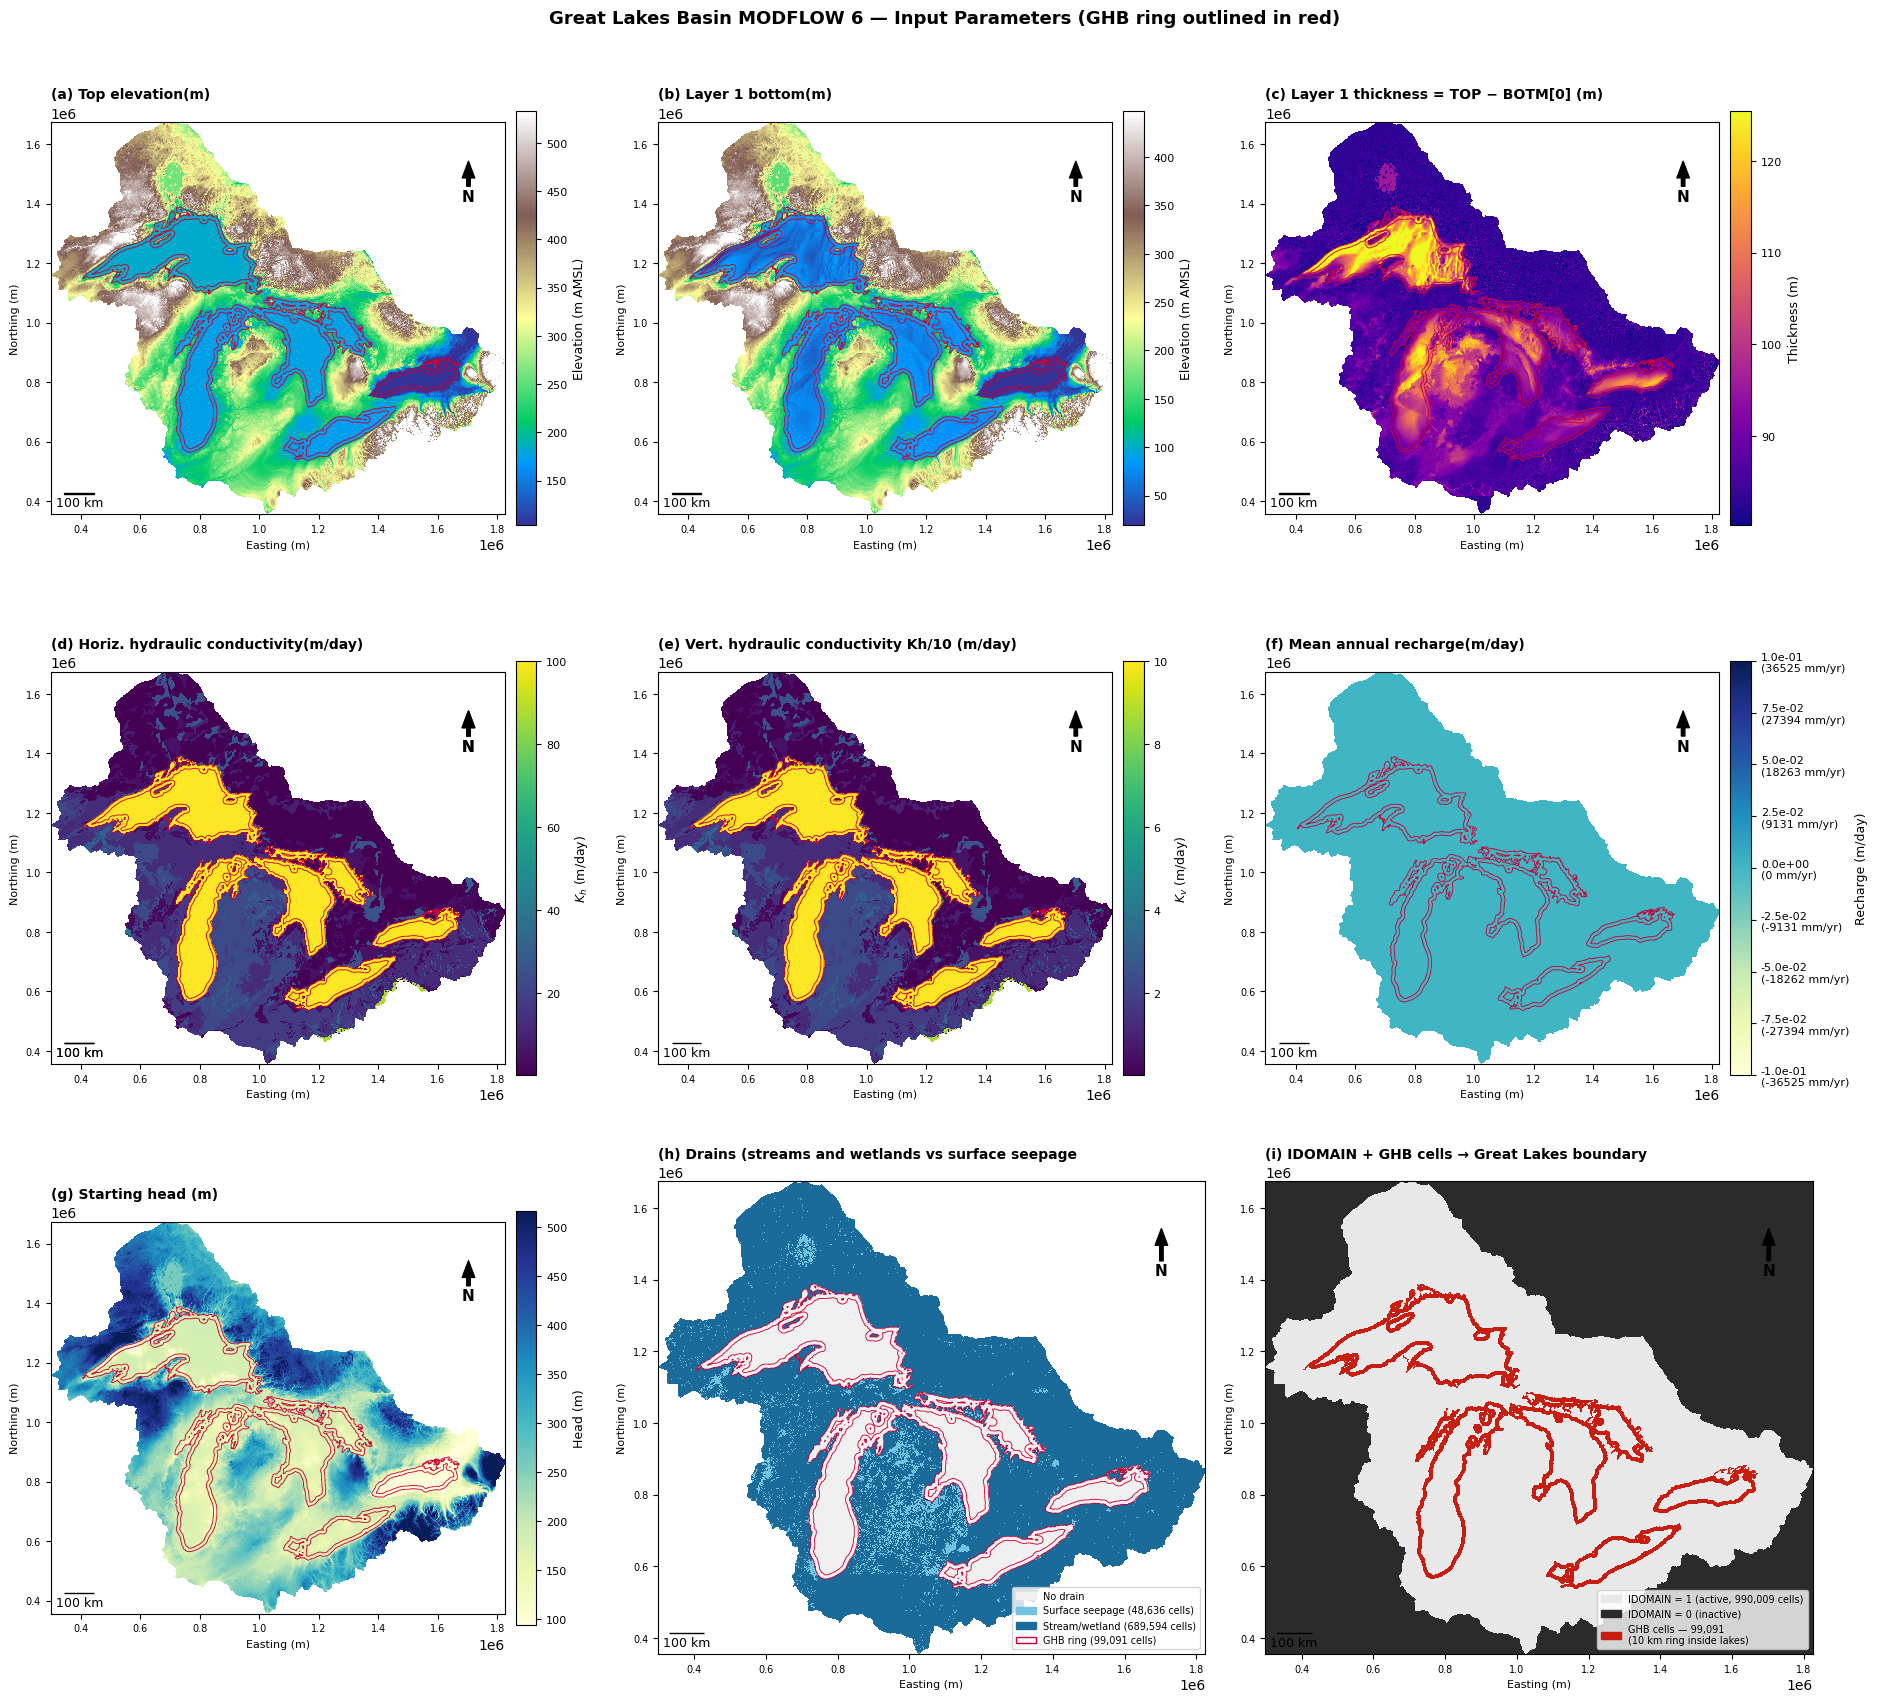

=== MODEL INPUT SUMMARY ===
Active cells total:           990,009
  terrestrial (land):         890,918
  GHB ring (in lake):          99,091

                       terrestrial        |   GHB ring
                  min      med     max    |  min    med    max
TOP           70 2.7e+02 1.1e+03 |     63 1.8e+02 4.4e+02 m
BOTM0        -47 1.9e+02 9.7e+02 |    -39     85 3.5e+02 m
THK1          26      86 1.9e+02 |     66     91  2e+02 m
HK0        1e-08      13   1e+02 | 0.0086  1e+02  1e+02 m/day
K33        1e-09     1.3      10 | 0.00086     10     10 m/day
STRT          50 2.6e+02   1e+03 |     50 1.7e+02  4e+02 m
RCH            0       0       0 |      0      0      0 m/day

DRN cells:  738,230
GHB cells:  99,091


In [56]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib.ticker import FixedLocator
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

# ---------------------------------------------------------
# helpers
# ---------------------------------------------------------
def get_plot_extent(xorigin, yorigin, delr, delc, nrow, ncol):
    return [xorigin,
            xorigin + np.sum(delr),
            yorigin,
            yorigin + np.sum(delc)]

def rec_list_to_mask(rec_list, nrow, ncol):
    mask = np.full((nrow, ncol), np.nan, dtype=float)
    if rec_list is None or len(rec_list) == 0:
        return mask
    for rec in rec_list:
        try:
            k, i, j = rec[0]
            if 0 <= i < nrow and 0 <= j < ncol:
                mask[i, j] = 1.0
        except Exception:
            continue
    return mask

def ghb_df_to_mask(ghb_cells_df, nrow, ncol):
    mask = np.full((nrow, ncol), np.nan, dtype=float)
    if ghb_cells_df is None or len(ghb_cells_df) == 0:
        return mask
    for r in ghb_cells_df.itertuples(index=False):
        i, j = int(r.i), int(r.j)
        if 0 <= i < nrow and 0 <= j < ncol:
            mask[i, j] = 1.0
    return mask

def active_array(arr, idomain2d):
    out = np.array(arr, dtype=float).copy()
    out[idomain2d <= 0] = np.nan
    return out

def pct(arr, lo, hi):
    v = arr[np.isfinite(arr)]
    return (float(np.nanpercentile(v, lo)),
            float(np.nanpercentile(v, hi))) if v.size else (0, 1)

def add_scalebar(ax, length_km=100):
    fp = fm.FontProperties(size=9)
    ax.add_artist(AnchoredSizeBar(
        ax.transData, length_km * 1000,
        f"{length_km} km", "lower left",
        pad=0.3, color="black", frameon=False,
        size_vertical=max(delc[0], delr[0]) * 1.5,
        fontproperties=fp))

def add_north(ax, x=0.92, y=0.90, size=0.09):
    ax.annotate("N", xy=(x, y), xytext=(x, y - size),
                xycoords="axes fraction", textcoords="axes fraction",
                ha="center", va="center",
                fontsize=11, fontweight="bold",
                arrowprops=dict(facecolor="black", edgecolor="black",
                                width=2.5, headwidth=9))

def add_cbar(fig, ax, im, label, fontsize=9):
    cb = fig.colorbar(im, ax=ax, shrink=0.82, pad=0.02)
    cb.set_label(label, fontsize=fontsize)
    cb.ax.tick_params(labelsize=8)
    return cb

def relabel_log_cbar(cb):
    ticks = cb.get_ticks()
    cb.ax.yaxis.set_major_locator(FixedLocator(ticks))
    cb.set_ticklabels([f"{10**t:.2g}" for t in ticks])

def relabel_rch_cbar(cb):
    ticks = cb.get_ticks()
    cb.ax.yaxis.set_major_locator(FixedLocator(ticks))
    cb.set_ticklabels([f"{v:.1e}\n({v*365.25*1000:.0f} mm/yr)"
                       for v in ticks])

# ---------------------------------------------------------
# prepare domain
# ---------------------------------------------------------
extent = get_plot_extent(xorigin, yorigin, delr, delc, nrow, ncol)

idomain2d = idomain[0] if idomain.ndim == 3 else id2d

# GHB cell mask directly from rebuilt GHB cells
ring_mask_2d = np.zeros((nrow, ncol), dtype=bool)
if "ghb_cells_df" in globals():
    for r in ghb_cells_df.itertuples(index=False):
        i, j = int(r.i), int(r.j)
        if 0 <= i < nrow and 0 <= j < ncol:
            ring_mask_2d[i, j] = True

n_ring = int(ring_mask_2d.sum())
print(f"GHB cells identified for overlay: {n_ring:,}")

def outline_ring(ax):
    if n_ring == 0:
        return
    ax.contour(
        ring_mask_2d.astype(float),
        levels=[0.5],
        colors="#cc0033",
        linewidths=0.6,
        extent=extent,
        origin="upper",
    )

# ---------------------------------------------------------
# arrays in MODEL UNITS as they enter MODFLOW 6
# ---------------------------------------------------------
top_plot = active_array(top2d, idomain2d)
bot1_plot = active_array(botm3d[0], idomain2d)
thk1_plot = active_array(top2d - botm3d[0], idomain2d)

hk1_plot = active_array(hk3d[0], idomain2d)
hk1_log  = np.log10(np.where(hk1_plot > 0, hk1_plot, np.nan))

k33_plot = active_array(k33_3d[0], idomain2d)
k33_log  = np.log10(np.where(k33_plot > 0, k33_plot, np.nan))

rch_all  = np.array([rch_spd[p] for p in range(len(rch_spd))], dtype=float)
rch_mean = np.nanmean(rch_all, axis=0)
rch_mday = active_array(rch_mean, idomain2d)

strt1_plot = active_array(strt[0] if strt.ndim == 3 else strt, idomain2d)

idomain_plot = np.where(idomain2d == 1, 1.0, np.nan)

drn_mask = rec_list_to_mask(drn_rec, nrow, ncol)

ghb_mask = ghb_df_to_mask(ghb_cells_df, nrow, ncol) \
           if "ghb_cells_df" in globals() \
           else np.full((nrow, ncol), np.nan, dtype=float)

# ---------------------------------------------------------
# color limits — computed on terrestrial cells only so the
# high-K ring doesn't blow out the land color range
# ---------------------------------------------------------
terrestrial_mask = (idomain2d == 1) & (~ring_mask_2d)

def pct_terrestrial(arr, lo, hi):
    v = arr[terrestrial_mask & np.isfinite(arr)]
    return (float(np.nanpercentile(v, lo)),
            float(np.nanpercentile(v, hi))) if v.size else (0, 1)

top_vmin,  top_vmax  = pct_terrestrial(top_plot,  2, 98)
bot_vmin,  bot_vmax  = pct_terrestrial(bot1_plot, 2, 98)
thk_vmin,  thk_vmax  = pct_terrestrial(thk1_plot, 2, 98)

hk1_log_terr = np.where(terrestrial_mask & (hk3d[0] > 0),
                        np.log10(hk3d[0]), np.nan)
k33_log_terr = np.where(terrestrial_mask & (k33_3d[0] > 0),
                        np.log10(k33_3d[0]), np.nan)

hk1_for_plot = active_array(hk3d[0], idomain2d)

# color range from terrestrial cells only (keeps the high-K ring from blowing out contrast)
hk_terr_vals = hk3d[0][terrestrial_mask]
hk_vmin = float(np.nanpercentile(hk_terr_vals[hk_terr_vals > 0], 2))
hk_vmax = float(np.nanpercentile(hk_terr_vals[hk_terr_vals > 0], 98))

##(e) Kv layer 1 — linear m/day
k33_for_plot = active_array(k33_3d[0], idomain2d)

k33_terr_vals = k33_3d[0][terrestrial_mask]
k33_vmin = float(np.nanpercentile(k33_terr_vals[k33_terr_vals > 0], 2))
k33_vmax = float(np.nanpercentile(k33_terr_vals[k33_terr_vals > 0], 98))


rch_vmin = 0.0
rch_vmax = float(np.nanpercentile(rch_mday[terrestrial_mask], 95))
strt_vmin, strt_vmax = pct_terrestrial(strt1_plot, 2, 98)

# ---------------------------------------------------------
# PLOT — 3x3 grid
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(19, 17))
axes = axes.ravel()
letters = [f"({x})" for x in "abcdefghi"]

def base_ax(ax, letter, title):
    ax.set_title(f"{letter} {title}", loc="left",
                 fontweight="bold", fontsize=10)
    ax.set_xlabel("Easting (m)", fontsize=8)
    ax.set_ylabel("Northing (m)", fontsize=8)
    ax.tick_params(labelsize=7)

# (a) Top elevation
im = axes[0].imshow(np.ma.masked_invalid(top_plot),
                    origin="upper", extent=extent,
                    cmap="terrain", vmin=top_vmin, vmax=top_vmax,
                    interpolation="nearest")
add_cbar(fig, axes[0], im, "Elevation (m AMSL)")
outline_ring(axes[0])
base_ax(axes[0], letters[0], "Top elevation(m)")
add_north(axes[0]); add_scalebar(axes[0])

# (b) Layer 1 bottom
im = axes[1].imshow(np.ma.masked_invalid(bot1_plot),
                    origin="upper", extent=extent,
                    cmap="terrain", vmin=bot_vmin, vmax=bot_vmax,
                    interpolation="nearest")
add_cbar(fig, axes[1], im, "Elevation (m AMSL)")
outline_ring(axes[1])
base_ax(axes[1], letters[1], "Layer 1 bottom(m)")
add_north(axes[1]); add_scalebar(axes[1])

# (c) Layer 1 thickness
im = axes[2].imshow(np.ma.masked_invalid(thk1_plot),
                    origin="upper", extent=extent,
                    cmap="plasma", vmin=thk_vmin, vmax=thk_vmax,
                    interpolation="nearest")
add_cbar(fig, axes[2], im, "Thickness (m)")
outline_ring(axes[2])
base_ax(axes[2], letters[2], "Layer 1 thickness = TOP − BOTM[0] (m)")
add_north(axes[2]); add_scalebar(axes[2])

# (d) Kh layer 1
im = axes[3].imshow(np.ma.masked_invalid(hk1_for_plot),
                    origin="upper", extent=extent,
                    cmap="viridis", vmin=hk_vmin, vmax=hk_vmax,
                    interpolation="nearest")
add_cbar(fig, axes[3], im, r"$K_h$ (m/day)")
outline_ring(axes[3])
base_ax(axes[3], letters[3],
        "Horiz. hydraulic conductivity(m/day)")
add_north(axes[3]); add_scalebar(axes[3])
add_north(axes[3]); add_scalebar(axes[3])

# (e)  Kv layer 1
im = axes[4].imshow(np.ma.masked_invalid(k33_for_plot),
                    origin="upper", extent=extent,
                    cmap="viridis", vmin=k33_vmin, vmax=k33_vmax,
                    interpolation="nearest")
add_cbar(fig, axes[4], im, r"$K_v$ (m/day)")
outline_ring(axes[4])
base_ax(axes[4], letters[4],
        "Vert. hydraulic conductivity Kh/10 (m/day)")
add_north(axes[4]); add_scalebar(axes[4])

# (f) Mean annual recharge
im = axes[5].imshow(np.ma.masked_invalid(rch_mday),
                    origin="upper", extent=extent,
                    cmap="YlGnBu", vmin=rch_vmin, vmax=rch_vmax,
                    interpolation="nearest")
cb = add_cbar(fig, axes[5], im, "Recharge (m/day)")
relabel_rch_cbar(cb)
outline_ring(axes[5])
rch_zero = 100 * np.mean(rch_mday[idomain2d > 0] < 1e-6)
# axes[5].text(0.02, 0.03,
#              f"Zero recharge: {rch_zero:.1f}% of domain",
#              transform=axes[5].transAxes, fontsize=8,
#              color="darkred",
#              bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
base_ax(axes[5], letters[5],
        "Mean annual recharge(m/day)")
add_north(axes[5]); add_scalebar(axes[5])

# (g) Starting head
im = axes[6].imshow(np.ma.masked_invalid(strt1_plot),
                    origin="upper", extent=extent,
                    cmap="YlGnBu",
                    vmin=strt_vmin, vmax=strt_vmax,
                    interpolation="nearest")
add_cbar(fig, axes[6], im, "Head (m)")
outline_ring(axes[6])
base_ax(axes[6], letters[6],
        "Starting head (m)")
add_north(axes[6]); add_scalebar(axes[6])

# (h) DRN cells
drn_type = np.zeros((nrow, ncol), dtype=float)
drn_type[idomain2d <= 0] = np.nan
for rec in drn_rec_clean:
    k, i, j = rec[0]
    drn_type[i, j] = 2.0
for rec in surf_rec:
    k, i, j = rec[0]
    if drn_type[i, j] != 2.0:
        drn_type[i, j] = 1.0

cmap_drn = ListedColormap(["#f0f0f0", "#74c2e1", "#1a6b9a"])
axes[7].imshow(np.ma.masked_invalid(drn_type),
               origin="upper", extent=extent,
               cmap=cmap_drn, vmin=0, vmax=2,
               interpolation="nearest")
outline_ring(axes[7])
axes[7].legend(handles=[
    Patch(color="#f0f0f0", label="No drain"),
    Patch(color="#74c2e1",
          label=f"Surface seepage ({len(surf_rec):,} cells)"),
    Patch(color="#1a6b9a",
          label=f"Stream/wetland ({len(drn_rec_clean):,} cells)"),
    Patch(edgecolor="#cc0033", facecolor="none",
          label=f"GHB ring ({n_ring:,} cells)"),
], loc="lower right", fontsize=7, frameon=True)
base_ax(axes[7], letters[7],
        "Drains (streams and wetlands vs surface seepage")
add_north(axes[7]); add_scalebar(axes[7])

# (i) GHB cells — show as filled ring with terrestrial background
idomain_bg = idomain2d.astype(float)
axes[8].imshow(idomain_bg,
               origin="upper", extent=extent,
               cmap=ListedColormap(["#2b2b2b", "#e8e8e8"]),  # dark grey = inactive, light grey = active
               vmin=0, vmax=1,
               interpolation="nearest")

# GHB cells on top
axes[8].imshow(np.ma.masked_invalid(ghb_mask),
               origin="upper", extent=extent,
               cmap=ListedColormap(["#c81d11"]),
               vmin=0.5, vmax=1.5,
               interpolation="nearest")

axes[8].legend(handles=[
    Patch(color="#e8e8e8", label=f"IDOMAIN = 1 (active, {int((idomain2d == 1).sum()):,} cells)"),
    Patch(color="#2b2b2b", label=f"IDOMAIN = 0 (inactive)"),
    Patch(color="#c81d11",
          label=f"GHB cells — {int(np.isfinite(ghb_mask).sum()):,}\n"
                f"(10 km ring inside lakes)"),
], loc="lower right", fontsize=7, frameon=True)
base_ax(axes[8], letters[8],
        "IDOMAIN + GHB cells → Great Lakes boundary")
add_north(axes[8]); add_scalebar(axes[8])

plt.suptitle(
    "Great Lakes Basin MODFLOW 6 — Input Parameters (GHB ring outlined in red)",
    fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig(r"D:\Users\abolmaal\modelling\Figs\Testing_6\modelinputs.jpeg",
            dpi=300, bbox_inches="tight")
plt.show()
# ---------------------------------------------------------
# summary in model units, split by terrestrial vs ring
# ---------------------------------------------------------
terr = terrestrial_mask
ring = ring_mask_2d

print("=== MODEL INPUT SUMMARY ===")
print(f"Active cells total:        {int(np.sum(idomain2d == 1)):>10,}")
print(f"  terrestrial (land):      {int(terr.sum()):>10,}")
print(f"  GHB ring (in lake):      {int(ring.sum()):>10,}")
print()
print("                       terrestrial        |   GHB ring")
print("                  min      med     max    |  min    med    max")
def row(name, arr, unit=""):
    t = arr[terr][np.isfinite(arr[terr])]
    r = arr[ring][np.isfinite(arr[ring])]
    print(f"{name:8s} "
          f"{t.min():>7.2g} {np.median(t):>7.2g} {t.max():>7.2g} "
          f"| {r.min():>6.2g} {np.median(r):>6.2g} {r.max():>6.2g} {unit}")
row("TOP",   top2d,                   "m")
row("BOTM0", botm3d[0],               "m")
row("THK1",  top2d - botm3d[0],       "m")
row("HK0",   hk3d[0],                 "m/day")
row("K33",   k33_3d[0],               "m/day")
row("STRT",  strt[0] if strt.ndim == 3 else strt, "m")
row("RCH",   rch_mean,                "m/day")
print()
print(f"DRN cells:  {len(drn_rec):,}")
print(f"GHB cells:  {int(np.isfinite(ghb_mask).sum()):,}")

## 14) Pre-run sanity checks

This is a good checkpoint before writing and running MODFLOW 6.
It checks:
- DRN conductance ranges
- duplicate drains
- DRN / GHB overlap
- GHB stage consistency
- recharge and head bounds


In [67]:
print("Recharge totals by stress period:")
for p in sorted(rch_spd.keys()):
    arr = np.asarray(rch_spd[p], dtype=float)
    arr = np.where(np.isfinite(arr), arr, 0.0)

    total = arr.sum() * float(delr[0] * delc[0])   # approximate if uniform 1000 m grid
    nonzero = int(np.count_nonzero(arr > 0))
    vmax = float(arr.max()) if arr.size else np.nan

    print(f"  period {p:2d}: total={total:.3e} m3/day, nonzero cells={nonzero:,}, max={vmax:.3e}")

Recharge totals by stress period:
  period  0: total=0.000e+00 m3/day, nonzero cells=0, max=0.000e+00
  period  1: total=0.000e+00 m3/day, nonzero cells=0, max=0.000e+00
  period  2: total=0.000e+00 m3/day, nonzero cells=0, max=0.000e+00
  period  3: total=0.000e+00 m3/day, nonzero cells=0, max=0.000e+00
  period  4: total=0.000e+00 m3/day, nonzero cells=0, max=0.000e+00
  period  5: total=0.000e+00 m3/day, nonzero cells=0, max=0.000e+00
  period  6: total=0.000e+00 m3/day, nonzero cells=0, max=0.000e+00
  period  7: total=0.000e+00 m3/day, nonzero cells=0, max=0.000e+00
  period  8: total=0.000e+00 m3/day, nonzero cells=0, max=0.000e+00
  period  9: total=0.000e+00 m3/day, nonzero cells=0, max=0.000e+00
  period 10: total=0.000e+00 m3/day, nonzero cells=0, max=0.000e+00
  period 11: total=0.000e+00 m3/day, nonzero cells=0, max=0.000e+00
  period 12: total=0.000e+00 m3/day, nonzero cells=0, max=0.000e+00


In [68]:
terr_mask = (idomain[0] > 0)
if "lake_mask_2d" in globals():
    terr_mask = terr_mask & (~lake_mask_2d)

print("\nRecharge over active land cells by period:")
for p in sorted(rch_spd.keys()):
    arr = np.asarray(rch_spd[p], dtype=float)
    vals = arr[terr_mask]
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        print(f"  period {p:2d}: no values")
    else:
        print(f"  period {p:2d}: min={vals.min():.3e}, p50={np.percentile(vals,50):.3e}, "
              f"p95={np.percentile(vals,95):.3e}, max={vals.max():.3e}, "
              f"nonzero={np.count_nonzero(vals>0):,}")


Recharge over active land cells by period:
  period  0: min=0.000e+00, p50=0.000e+00, p95=0.000e+00, max=0.000e+00, nonzero=0
  period  1: min=0.000e+00, p50=0.000e+00, p95=0.000e+00, max=0.000e+00, nonzero=0
  period  2: min=0.000e+00, p50=0.000e+00, p95=0.000e+00, max=0.000e+00, nonzero=0
  period  3: min=0.000e+00, p50=0.000e+00, p95=0.000e+00, max=0.000e+00, nonzero=0
  period  4: min=0.000e+00, p50=0.000e+00, p95=0.000e+00, max=0.000e+00, nonzero=0
  period  5: min=0.000e+00, p50=0.000e+00, p95=0.000e+00, max=0.000e+00, nonzero=0
  period  6: min=0.000e+00, p50=0.000e+00, p95=0.000e+00, max=0.000e+00, nonzero=0
  period  7: min=0.000e+00, p50=0.000e+00, p95=0.000e+00, max=0.000e+00, nonzero=0
  period  8: min=0.000e+00, p50=0.000e+00, p95=0.000e+00, max=0.000e+00, nonzero=0
  period  9: min=0.000e+00, p50=0.000e+00, p95=0.000e+00, max=0.000e+00, nonzero=0
  period 10: min=0.000e+00, p50=0.000e+00, p95=0.000e+00, max=0.000e+00, nonzero=0
  period 11: min=0.000e+00, p50=0.000e+00, 

In [66]:
import numpy as np
import pandas as pd

print("=" * 60)
print("SANITY CHECKS BEFORE RUNNING MODFLOW 6")
print("=" * 60)

# ---------------------------------------------------------
# 1) SURFACE SEEPAGE CONDUCTANCE
# ---------------------------------------------------------
print("\n--- 1) Surface seepage conductance ---")
surf_conds = np.array([r[2] for r in surf_drn_rec])
print(f"  Csurf min:    {surf_conds.min():.3e} m²/day")
print(f"  Csurf max:    {surf_conds.max():.3e} m²/day")
print(f"  Csurf median: {np.median(surf_conds):.3e} m²/day")
print(f"  Cells at cap (1e4): {np.sum(surf_conds >= 9999):.0f}")

if surf_conds.max() > 1e6:
    print("  ❌ FAIL — Csurf max > 1e6, TSOIL/SURF_AREA_FRAC fix not applied")
elif surf_conds.max() > 1e5:
    print("  ⚠️  WARNING — Csurf max > 1e5, consider lowering SURF_COND_CAP")
else:
    print("  ✅ PASS — conductance range looks reasonable")

# ---------------------------------------------------------
# 2) DRAIN RECORD COUNTS AND NO DUPLICATES
# ---------------------------------------------------------
print("\n--- 2) DRN record counts ---")
print(f"  Stream/wetland records: {len(drn_rec_clean):,}")
print(f"  Surface seepage records: {len(surf_rec):,}")
print(f"  Total drn_rec: {len(drn_rec):,}")

# check for duplicate (i,j) cells in final drn_rec
ij_list = [(r[0][1], r[0][2]) for r in drn_rec]
ij_set  = set(ij_list)
n_dups  = len(ij_list) - len(ij_set)
print(f"  Duplicate (i,j) cells: {n_dups}")
if n_dups > 0:
    print("  ❌ FAIL — duplicate drain cells will cause MODFLOW budget errors")
else:
    print("  ✅ PASS — no duplicate drain cells")

# ---------------------------------------------------------
# 3) OVERLAP BETWEEN DRN AND GHB
# ---------------------------------------------------------
print("\n--- 3) DRN / GHB overlap ---")
drn_ij = {(r[0][1], r[0][2]) for r in drn_rec}
ghb_ij = {(int(r.i), int(r.j)) for r in ghb_cells_df.itertuples()}
overlap = drn_ij & ghb_ij
print(f"  DRN cells:  {len(drn_ij):,}")
print(f"  GHB cells:  {len(ghb_ij):,}")
print(f"  Overlap:    {len(overlap)}")
if len(overlap) > 0:
    print("  ❌ FAIL — DRN and GHB share cells, remove overlap before running")
else:
    print("  ✅ PASS — no DRN/GHB overlap")

# ---------------------------------------------------------
# 4) GHB STAGE vs CELL TOP
# ---------------------------------------------------------
print("\n--- 4) GHB stage vs land surface (top_cap check) ---")
if "top_cap" not in ghb_cells_df.columns:
    print("  ⚠️  top_cap column missing — GHB stage cap fix not applied")
else:
    rr = ghb_cells_df["i"].to_numpy(dtype=int)
    cc = ghb_cells_df["j"].to_numpy(dtype=int)
    first_per_stages = np.array([
        float(monthly_stages_model.loc[model_months[0], r.stage_name])
        for r in ghb_cells_df.itertuples(index=False)
    ])
    capped_stages = np.array([
        min(float(monthly_stages_model.loc[model_months[0], r.stage_name]),
            float(r.top_cap) - 0.10)
        for r in ghb_cells_df.itertuples(index=False)
    ])
    n_above = np.sum(first_per_stages > top2d[rr, cc])
    n_capped = np.sum(capped_stages < first_per_stages)
    print(f"  GHB cells where raw stage > top2d:   {n_above:,}")
    print(f"  GHB cells where stage was capped:    {n_capped:,}")
    if n_above > 0 and n_capped == 0:
        print("  ❌ FAIL — stage cap fix not active in ghb_spd loop")
    else:
        print("  ✅ PASS — stage cap applied to all cells above land surface")

# ---------------------------------------------------------
# 5) STARTING HEADS WITHIN VALID RANGE
# ---------------------------------------------------------
print("\n--- 5) Starting heads ---")
active = idomain[0] > 0
strt1 = strt[0]
above_top  = np.sum(strt1[active] > top2d[active])
below_bot  = np.sum(strt1[active] < botm3d[0][active])
print(f"  Cells with head > top2d:   {above_top:,}")
print(f"  Cells with head < botm[0]: {below_bot:,}")
print(f"  Head min/max (active): "
      f"{strt1[active].min():.1f} / {strt1[active].max():.1f} m")
if above_top > 0:
    print("  ⚠️  WARNING — some starting heads above land surface")
if below_bot > 0:
    print("  ❌ FAIL — some starting heads below cell bottom, model will fail")
else:
    print("  ✅ PASS — all starting heads above cell bottom")

# ---------------------------------------------------------
# 6) LAYER THICKNESS
# ---------------------------------------------------------
print("\n--- 6) Layer thickness ---")
for k in range(nlay):
    if k == 0:
        thk = top2d - botm3d[0]
    else:
        thk = botm3d[k-1] - botm3d[k]
    thk_active = thk[idomain[k] > 0]
    n_thin = np.sum(thk_active <= 0)
    print(f"  Layer {k+1}: min={thk_active.min():.2f} m  "
          f"max={thk_active.max():.1f} m  "
          f"cells <= 0m: {n_thin}")
    if n_thin > 0:
        print(f"  ❌ FAIL — Layer {k+1} has zero or negative thickness cells")

# ---------------------------------------------------------
# 7) RECHARGE BUDGET VS DRAIN CAPACITY
# ---------------------------------------------------------
print("\n--- 7) Recharge vs drain budget (period 0) ---")
rch0 = rch_spd[0]
active2d = (id2d == 1)

total_rch_m3day = float(np.sum(
    rch0[active2d] * delr[np.where(active2d)[1]] * delc[np.where(active2d)[0]]
))

# surface seepage max possible outflow (if all heads at drain elev)
surf_cond_arr = np.array([r[2] for r in surf_drn_rec])
# max outflow if head were 1 m above drain elevation everywhere
surf_max_out = float(np.sum(surf_cond_arr * 1.0))

print(f"  Total recharge period 0:        {total_rch_m3day:.3e} m³/day")
print(f"  Surface seepage max outflow*:   {surf_max_out:.3e} m³/day")
print(f"  (* if heads were 1m above drain elevation everywhere)")
ratio = surf_max_out / total_rch_m3day if total_rch_m3day > 0 else np.inf
print(f"  Ratio (seepage capacity / recharge): {ratio:.2f}")
if ratio > 100:
    print("  ❌ FAIL — drain capacity >> recharge, model will over-drain")
elif ratio > 10:
    print("  ⚠️  WARNING — drain capacity 10x recharge, watch for drainage")
else:
    print("  ✅ PASS — drain capacity in reasonable range vs recharge")

# ---------------------------------------------------------
# 8) HK RANGE
# ---------------------------------------------------------
print("\n--- 8) Hydraulic conductivity ---")
for k in range(nlay):
    hk_active = hk3d[k][idomain[k] > 0]
    print(f"  Layer {k+1}: min={hk_active.min():.2e}  "
          f"max={hk_active.max():.2e}  "
          f"median={np.median(hk_active):.2e} m/day")

# ---------------------------------------------------------
# 9) STRESS PERIOD COUNT CONSISTENCY
# ---------------------------------------------------------
print("\n--- 9) Stress period consistency ---")
print(f"  perioddata_run:  {len(perioddata_run)} periods")
print(f"  rch_spd:         {len(rch_spd)} periods")
print(f"  ghb_spd:         {len(ghb_spd)} periods")

ok = (len(rch_spd) == len(perioddata_run) == len(ghb_spd))
if not ok:
    print("  ❌ FAIL — period counts do not match")
else:
    print("  ✅ PASS — all packages have same number of stress periods")

# ---------------------------------------------------------
# 10) k33 ANISOTROPY
# ---------------------------------------------------------
print("\n--- 10) Vertical K (k33) anisotropy ---")
if "k33_3d" not in globals():
    print("  ❌ FAIL — k33_3d not defined, NPF will use isotropic K")
else:
    for k in range(nlay):
        hk_act = hk3d[k][idomain[k] > 0]
        kv_act = k33_3d[k][idomain[k] > 0]
        ratio  = hk_act / kv_act
        print(f"  Layer {k+1}: Kh/Kv ratio "
              f"min={ratio.min():.1f}  max={ratio.max():.1f}  "
              f"median={np.median(ratio):.1f}")
    print("  ✅ k33_3d defined")

print("\n" + "=" * 60)
print("SANITY CHECKS COMPLETE")
print("=" * 60)

SANITY CHECKS BEFORE RUNNING MODFLOW 6

--- 1) Surface seepage conductance ---
  Csurf min:    1.000e-01 m²/day
  Csurf max:    1.000e-01 m²/day
  Csurf median: 1.000e-01 m²/day
  Cells at cap (1e4): 0
  ✅ PASS — conductance range looks reasonable

--- 2) DRN record counts ---
  Stream/wetland records: 689,594
  Surface seepage records: 48,636
  Total drn_rec: 738,230
  Duplicate (i,j) cells: 0
  ✅ PASS — no duplicate drain cells

--- 3) DRN / GHB overlap ---
  DRN cells:  738,230
  GHB cells:  99,091
  Overlap:    0
  ✅ PASS — no DRN/GHB overlap

--- 4) GHB stage vs land surface (top_cap check) ---
  GHB cells where raw stage > top2d:   39,666
  GHB cells where stage was capped:    54,274
  ✅ PASS — stage cap applied to all cells above land surface

--- 5) Starting heads ---
  Cells with head > top2d:   0
  Cells with head < botm[0]: 0
  Head min/max (active): 50.0 / 999.9 m
  ✅ PASS — all starting heads above cell bottom

--- 6) Layer thickness ---
  Layer 1: min=25.97 m  max=201.3 m

## 15) Build and run MODFLOW 6

This section writes the simulation and runs it.


In [ ]:
# Close possible open handles from earlier tests
for varname in ["cbc", "hds", "bud", "headfile", "cellbudgetfile", "hdobj", "cbbobj"]:
    obj = globals().get(varname, None)
    try:
        if obj is not None and hasattr(obj, "close"):
            obj.close()
            print(f"Closed {varname}")
    except Exception as e:
        print(f"Could not close {varname}: {repr(e)}")

if os.path.isdir(sim_ws):
    safe_rmtree(sim_ws)
os.makedirs(sim_ws, exist_ok=True)

sim = flopy.mf6.MFSimulation(sim_name=nameSim, sim_ws=sim_ws, exe_name=exe_path)

tdis = flopy.mf6.ModflowTdis(
    sim,
    time_units="DAYS",
    nper=len(perioddata_run),
    perioddata=perioddata_run,
    start_date_time=START_DATE,
)
# Steady state spin-up in period 0, then transient periods 1+ with same length as perioddata_run
ims = flopy.mf6.ModflowIms(
    sim,
    pname="ims",
    complexity="MODERATE",
    outer_maximum=500,          # increased from 100
    inner_maximum=300,          # increased from 200
    outer_dvclose=1e-3,         # tightened from 1e-2
    inner_dvclose=1e-3,         # tightened from 1e-2
    rcloserecord=1e-3,          # tightened from 1e-2
    linear_acceleration="BICGSTAB",
    under_relaxation="DBD",
    under_relaxation_theta=0.9,  # add damping
    under_relaxation_kappa=0.0001,
    under_relaxation_gamma=0.0,
    print_option="SUMMARY",
    filename=f"{nameModel}.ims",
)

gwf = flopy.mf6.ModflowGwf(sim, modelname=nameModel, save_flows=True)
sim.register_ims_package(ims, [gwf.name])

dis = flopy.mf6.ModflowGwfdis(
    gwf,
    nlay=nlay, nrow=nrow, ncol=ncol,
    delr=delr, delc=delc,
    top=top2d,
    botm=botm3d,
    idomain=idomain,
    xorigin=xorigin, yorigin=yorigin,
)

icelltype = [1] + [0] * (nlay - 1)

npf = flopy.mf6.ModflowGwfnpf(
    gwf,
    icelltype=icelltype,
    k=hk3d,
    k33=k33_3d,
    save_specific_discharge=True,
)

ic = flopy.mf6.ModflowGwfic(gwf, strt=strt)

# ---- CHANGED: period 0 = steady-state spin-up, periods 1+ = transient ----
sto = flopy.mf6.ModflowGwfsto(
    gwf,
    ss=1e-6,
    sy=0.1,
    steady_state=False,
    transient=True,
)


oc = flopy.mf6.ModflowGwfoc(
    gwf,
    head_filerecord=f"{nameModel}.hds",
    budget_filerecord=f"{nameModel}.cbb",
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
    printrecord=[("HEAD", "LAST"), ("BUDGET", "LAST")],
)

drn_rec = drn_rec if "drn_rec" in globals() else []
wet_drn_rec = wet_drn_rec if "wet_drn_rec" in globals() else []

if USE_DRN and len(drn_rec) > 0:
    drn_spd = {per: drn_rec for per in range(len(perioddata_run))}
    drn = flopy.mf6.ModflowGwfdrn(
        gwf,
        pname="DRN",
        filename=f"{nameModel}.drn",
        maxbound=len(drn_rec),
        stress_period_data=drn_spd,
        save_flows=True,
    )
    print("✅ DRN package added:", len(drn_rec), "cells")
    print("   DRN stress periods:", len(drn_spd))
else:
    print("Skipping DRN package")

if USE_GHB:
    if "ghb_spd" not in globals():
        raise ValueError("ghb_spd does not exist. Run Part 10 first.")
    if ghb_spd is None:
        raise ValueError("ghb_spd is None. Check Part 10.")
    if len(ghb_spd) == 0:
        raise ValueError("ghb_spd is empty. Check Part 10.")

if USE_GHB and ghb_spd is not None:
    print("Using GHB stress periods:", len(ghb_spd))
    print("Using GHB maxbound:", max(len(v) for v in ghb_spd.values()))
    if "ghb_cells_df" in globals():
        print("Using GHB lakes:", sorted(ghb_cells_df["lake_name"].unique()))

    ghb = flopy.mf6.ModflowGwfghb(
        gwf,
        pname="GHB_gl",
        filename=f"{nameModel}.ghb",
        boundnames=True,
        print_input=True,
        save_flows=True,
        maxbound=max(len(v) for v in ghb_spd.values()),
        stress_period_data=ghb_spd,
    )
    print("✅ GHB package added")
else:
    print("Skipping GHB package")

rcha = flopy.mf6.ModflowGwfrcha(
    gwf,
    pname="RCHA",
    filename=f"{nameModel}.rcha",
    recharge=rch_spd,
)
print("✅ RCH package added:", len(rch_spd), "periods")

# ---- ADDED: final consistency check before writing ----
print("\n--- Final period count check ---")
print(f"perioddata_run: {len(perioddata_run)}")
print(f"rch_spd:        {len(rch_spd)}")
print(f"ghb_spd:        {len(ghb_spd)}")
print(f"drn_spd:        {len(drn_spd)}")
assert len(rch_spd) == len(perioddata_run), \
    f"rch_spd has {len(rch_spd)} periods, expected {len(perioddata_run)}"
assert len(ghb_spd) == len(perioddata_run), \
    f"ghb_spd has {len(ghb_spd)} periods, expected {len(perioddata_run)}"
assert len(drn_spd) == len(perioddata_run), \
    f"drn_spd has {len(drn_spd)} periods, expected {len(perioddata_run)}"
print("✅ All period counts match — safe to write and run")

def rec_to_set(rec_list):
    out = set()
    for rec in rec_list:
        try:
            k, i, j = rec[0]
            out.add((int(k), int(i), int(j)))
        except Exception:
            pass
    return out

drn_set = rec_to_set(drn_rec)
wet_drn_set = rec_to_set(wet_drn_rec)

ghb_set = set()
if "ghb_spd" in globals() and ghb_spd is not None:
    for per, recs in ghb_spd.items():
        for rec in recs:
            try:
                k, i, j = rec[0]
                ghb_set.add((int(k), int(i), int(j)))
            except Exception:
                pass

print("DRN ∩ wetland DRN:", len(drn_set & wet_drn_set))
print("DRN ∩ GHB:", len(drn_set & ghb_set))
print("wetland DRN ∩ GHB:", len(wet_drn_set & ghb_set))

In [ ]:
sim.write_simulation()
success, buff = sim.run_simulation()
print("Run success:", success)
if not success:
    with open(os.path.join(sim_ws, f"{nameModel}.lst")) as f:
        lines = f.readlines()
    print("".join(lines[-50:]))

## 16) Optional: export warm-start heads from the previous run

Use this if you want to rerun with a better initial head field.


In [ ]:
#Extract the head from this simulation
import flopy.utils.binaryfile as bf
import numpy as np

head_path = os.path.join(sim_ws, f"{nameModel}.hds")
hds = bf.HeadFile(head_path)
times = hds.get_times()
h_final = hds.get_data(totim=times[-1])

# clean up placeholder values
h_warmstart = h_final.copy()
for k in range(nlay):
    dry = np.abs(h_warmstart[k]) >= 1e20
    h_warmstart[k][dry] = botm3d[k][dry] + 1.0

# FIXED — idomain is 3D so index matches h_warmstart shape
h_warmstart[idomain <= 0] = 0.0

# cap heads at land surface — prevents artesian start
for k in range(nlay):
    active = idomain[k] > 0
    above_top = active & (h_warmstart[k] > top2d)
    h_warmstart[k][above_top] = top2d[above_top] - 0.1
    print(f"Layer {k+1}: capped {above_top.sum():,} cells above land surface")

warmstart_path = os.path.join(
    r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers",
    "warmstart_heads.npy"
)
np.save(warmstart_path, h_warmstart)
print(f"\nWarm start heads saved: {warmstart_path}")
print(f"Shape: {h_warmstart.shape}")
print(f"Layer 1 min/max: "
      f"{h_warmstart[0][idomain[0]>0].min():.1f} / "
      f"{h_warmstart[0][idomain[0]>0].max():.1f} m")

## 17) Optional: listing-file budget summary

This reads the MF6 listing file and prints the flux budget and percent discrepancy.


In [ ]:
import flopy
import pandas as pd
import numpy as np
import os

# ---------------------------------------------------------
# MODFLOW 6 budget from listing file
# ---------------------------------------------------------
lst_path = os.path.join(sim_ws, f"{nameModel}.lst")

# MF6 uses Mf6ListBudget, not MfListBudget
mf_list = flopy.utils.Mf6ListBudget(lst_path)
df_flux, df_vol = mf_list.get_dataframes(start_datetime=START_DATE, diff=True)

print("=== FLUX BUDGET (m³/day) ===")
print(df_flux.to_string())

print("\n=== PERCENT DISCREPANCY ===")
# discrepancy column is usually named 'PERCENT_DISCREPANCY' or similar
disc_cols = [c for c in df_flux.columns if "DISCREPANCY" in c.upper() or "PERCENT" in c.upper()]
if disc_cols:
    print(df_flux[disc_cols])
else:
    print("Discrepancy column not found — printing all columns:")
    print(df_flux.columns.tolist())

## 18) Optional: example post-processing

The original notebook had many exploratory post-processing cells.  
This notebook keeps one representative post-processing figure cell as a starting point.


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.colors import TwoSlopeNorm
import flopy
import flopy.utils.binaryfile as bf

# ============================================================
# SETTINGS
# ============================================================
boundary_shp = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Ibound\extended_Bdry_final_GLB_Albers.shp"
save_fig = True
out_fig = r"D:\Users\abolmaal\modelling\Figs\avg_dtw_avg_recharge_studyperiod.png"

# if head is not already loaded
if "head" not in globals():
    head_path = os.path.join(sim_ws, f"{nameModel}.hds")
    hds = bf.HeadFile(head_path)
    times = hds.get_times()
    head = np.array([hds.get_data(totim=t) for t in times], dtype=float)
    print("Loaded head array:", head.shape)

# top from model
top = np.array(gwf.dis.top.array, dtype=float)

# ============================================================
# HELPERS
# ============================================================
def get_water_table(head3d, idomain3d, huge=1e20):
    nlay, nrow, ncol = head3d.shape
    wt = np.full((nrow, ncol), np.nan, dtype=float)

    for k in range(nlay):
        hk = np.array(head3d[k], dtype=float)
        hk[np.abs(hk) >= huge] = np.nan
        hk[idomain3d[k] <= 0] = np.nan

        take = np.isnan(wt) & np.isfinite(hk)
        wt[take] = hk[take]

    return wt

def get_depth_to_water(head_t, idomain, top, clip_negative=False):
    wt = get_water_table(head_t, idomain)
    dtw = np.array(top, dtype=float) - wt
    dtw[~np.isfinite(wt)] = np.nan

    if clip_negative:
        dtw = np.where(np.isfinite(dtw), np.maximum(dtw, 0.0), np.nan)

    return dtw

def robust_limits(arr, qlow=2, qhigh=98, symmetric=False):
    a = np.asarray(arr, dtype=float)
    a = a[np.isfinite(a)]

    if a.size == 0:
        return 0.0, 1.0

    vmin = float(np.nanpercentile(a, qlow))
    vmax = float(np.nanpercentile(a, qhigh))

    if symmetric:
        vmax_abs = max(abs(vmin), abs(vmax))
        return -vmax_abs, vmax_abs

    return vmin, vmax

def get_extent(xorigin, yorigin, delr, delc, nrow, ncol):
    if np.ndim(delr) == 0:
        width = ncol * float(delr)
    else:
        width = float(np.sum(delr))

    if np.ndim(delc) == 0:
        height = nrow * float(delc)
    else:
        height = float(np.sum(delc))

    return [xorigin, xorigin + width, yorigin, yorigin + height]

# ============================================================
# 1) AVERAGE DEPTH TO WATER
# ============================================================
dtw_all = np.array([
    get_depth_to_water(head[i], idomain, top, clip_negative=False)
    for i in range(head.shape[0])
])

avg_dtw = np.nanmean(dtw_all, axis=0)

# optional: mask inactive cells again
avg_dtw = np.where(idomain[0] > 0, avg_dtw, np.nan)

# ============================================================
# 2) AVERAGE RECHARGE
# ============================================================
if isinstance(rch_spd, dict):
    rch_arrays = []
    for per in sorted(rch_spd.keys()):
        arr = np.array(rch_spd[per], dtype=float)

        # if recharge is given as 3D, use top layer / first slice
        if arr.ndim == 3:
            arr = arr[0]

        rch_arrays.append(arr)

    rch_all = np.array(rch_arrays, dtype=float)

else:
    arr = np.array(rch_spd, dtype=float)
    if arr.ndim == 3:
        rch_all = arr
    elif arr.ndim == 2:
        rch_all = arr[np.newaxis, :, :]
    else:
        raise ValueError("rch_spd has an unsupported shape")

avg_rch = np.nanmean(rch_all, axis=0)
avg_rch = np.where(idomain[0] > 0, avg_rch, np.nan)

# ============================================================
# 3) COLOR LIMITS
# ============================================================
dtw_vmin, dtw_vmax = robust_limits(avg_dtw, qlow=2, qhigh=98, symmetric=True)
dtw_norm = TwoSlopeNorm(vmin=dtw_vmin, vcenter=0.0, vmax=dtw_vmax)

rch_vmin, rch_vmax = robust_limits(avg_rch, qlow=2, qhigh=98, symmetric=False)

# ============================================================
# 4) BOUNDARY
# ============================================================
gdf_bdry = gpd.read_file(boundary_shp)
try:
    if getattr(gwf.modelgrid, "crs", None) is not None:
        gdf_bdry = gdf_bdry.to_crs(gwf.modelgrid.crs)
except Exception:
    pass

extent = get_extent(xorigin, yorigin, delr, delc, nrow, ncol)

# ============================================================
# 5) PLOT
# ============================================================
# ============================================================
# 5) PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# ---- Average DTW
ax = axes[0]
im1 = ax.imshow(
    np.ma.masked_invalid(avg_dtw),
    origin="upper",
    extent=extent,
    cmap="RdBu",
    norm=dtw_norm,
)
gdf_bdry.boundary.plot(ax=ax, color="black", linewidth=0.8)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.text(
    0.02, 0.98, "a)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=14, fontweight="bold"
)
cbar1 = fig.colorbar(im1, ax=ax, shrink=0.82, extend="both")
cbar1.set_label("Average depth to water (m)")

# ---- Average Recharge
ax = axes[1]
im2 = ax.imshow(
    np.ma.masked_invalid(avg_rch),
    origin="upper",
    extent=extent,
    cmap="Blues",
    vmin=rch_vmin,
    vmax=rch_vmax,
)
gdf_bdry.boundary.plot(ax=ax, color="black", linewidth=0.8)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.text(
    0.02, 0.98, "b)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=14, fontweight="bold"
)
cbar2 = fig.colorbar(im2, ax=ax, shrink=0.82, extend="max")
cbar2.set_label("Average recharge (m/day)")

plt.show()

if save_fig:
    fig.savefig(out_fig, dpi=300, bbox_inches="tight")
    print("Saved:", out_fig)

# ============================================================
# 6) SUMMARY
# ============================================================
print("Average DTW min/max:", np.nanmin(avg_dtw), np.nanmax(avg_dtw))
print("Average recharge min/max:", np.nanmin(avg_rch), np.nanmax(avg_rch))